# GFDL meridional overturning circulation (MOC/AMOC/IPMOC)

Time-mean (1988-2012) meridional overturning streamfunctions for GFDL's 4
forced-ocean experiments (CTRL, bANN, uANN, bANN_uANN), computed with
`mom6_tools.moc_sigma2` on the native MOM6 tripolar grid (see
`gfdl_shim_moc.py` and `yamls/gfdl_*_moc.yaml`). Since there is no
observational MOC product to compare against, every panel below shows
**absolute** overturning (Sv) side by side across the 4 experiments, not a
bias/response -- matching how `key_diagnostics.ipynb`'s own MOC sections work.

**What's available and what isn't:**

- **Only density (sigma2) space is computable, not depth (z) space.**
  `mom6_tools.moc` (the z-space script) reads its transport variables
  (`vmo`/`vhml`/`vhGM`) from the **`'z'` Fnames stream**, but GFDL's
  z-coordinate stream (`ocean_monthly_z_1x1deg`) is a *regridded* diagnostic
  product with no transport variables at all. Only the **native**
  `ocean_annual_rho2` stream carries real `vmo`/`vhml`/`volcello`, on GFDL's
  own tripolar C-grid, in density (rho2/$\sigma_2$) coordinates -- so only
  `mom6_tools.moc_sigma2` is usable here. `moc_sigma2` also stores a
  `depth`/`amoc_depth`/`ipmoc_depth` coordinate (the zonal-mean depth of each
  density surface), letting the same result be viewed in depth space too.
  That depth coordinate is itself 2D (varies by latitude, following real
  bathymetry) and is plotted as such below -- an earlier version of this
  notebook collapsed it to a single latitude-averaged profile, which
  incorrectly flattened the ocean floor to one depth at every latitude.
- **The GM/mesoscale component (`moc_GM`) is a zero placeholder, not real
  data.** GFDL's `diag_table` never saved `vhGM` (the Gent-McWilliams
  thickness-diffusion bolus transport) -- it is architecturally missing, not
  just small. It's shown below purely for schema completeness; treat it as
  "unavailable", not as "GM transport is negligible here".
- **AMOC/IPMOC use `mom6_tools.m6toolbox.genBasinMasks`** (hardcoded seed
  points/cutting lines originally tuned for CESM's tripolar grid) applied to
  GFDL's native grid for the first time this session. The resulting AMOC
  shows a smooth, single-peaked NADW-type cell (~16-18 Sv peak near 47N,
  tapering toward the Arctic) and IPMOC a plausible ~11-15 Sv peak
  concentrated in tropical/subtropical latitudes -- both consistent with
  known large-scale ocean circulation, not noise, giving reasonable
  confidence the basin masks are usable **within the latitude range the
  vendored scripts themselves plot them over**. Outside that range,
  `genBasinMasks` has a hardcoded Atlantic/Indo-Pacific cutting latitude --
  checked directly, GFDL's grid reclassifies ~300 cells from Indo-Pacific to
  Atlantic in a single grid row at exactly -34.5 -- where the two basins
  stop being well-defined, separate regions and the mask assignment jumps
  discontinuously. Every AMOC/IPMOC panel below is clipped to the same
  latitude bounds `moc_sigma2.py`/`moc.py` already use for their own plots
  (`ATL_XLIM = (-40, 75)`, `IP_XLIM = (-34.5, 50)`) specifically to stay
  clear of this.
- **The output file's `yq` coordinate is a bare grid index** (0..1161), not
  latitude. This notebook instead builds its own approximate latitude axis
  from the zonal mean of the native grid's `geolat_v` field, which is exact
  in the well-behaved mid/low latitudes and only approximate near the
  Arctic/tripolar-fold region -- the same kind of approximation already
  implicit whenever `mom6_tools.moc`/`moc_sigma2`'s own plots treat `yq` as
  if it were latitude.

Two bugs in the vendored `mom6-tools/mom6_tools/moc_sigma2.py` were found and
fixed while preparing this: (1) a stray duplicate assignment that silently
overwrote `moc_FFH` (meant to hold the submesoscale/`vhml`-based overturning)
with the *total* overturning instead; (2) a hardcoded assumption that a
model's `yq` coordinate always follows CESM's "right" MOM6 grid convention
(`len(yq) == len(yh)`) -- GFDL's native grid instead uses the "outer"
convention (`len(yq) == len(yh) + 1`), which was crashing every MOC field's
depth-coordinate computation. Both fixes are backward-compatible with CESM's
own grid (auto-detected from the grid's own dimension sizes, not hardcoded).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

from experiment import Experiment

# mom6_tools.m6plot forces matplotlib.use('Agg') at import time -- re-assert
# Jupyter's inline backend afterward (see gfdl_horizontal_biases.ipynb).
from mom6_tools.m6plot import myStats
%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
MOC_DIR = os.path.join(REPO, 'data', 'gfdl_moc_1988_2012')

print('REPO    =', REPO)
print('MOC_DIR =', MOC_DIR)

Basemap module not found. Some regional plots may not function properly
REPO    = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
MOC_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_moc_1988_2012


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


In [2]:
# (name, folder) for each experiment. YAML config is yamls/<expt>_moc.yaml.
# name includes the '_moc' suffix -- this shim uses a separate CASEROOT/CASE
# from the T/S notebooks (native grid, not the regridded 1x1deg grid).
experiment_defs = [
    ('gfdl_CTRL_moc',       'CTRL'),
    ('gfdl_bANN_moc',       'bANN'),
    ('gfdl_uANN_moc',       'uANN'),
    ('gfdl_bANN_uANN_moc',  'bANN_uANN'),
]

exps = {}
lat1d = {}
for name, expt in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'gfdl_{expt}_moc.yaml')
    exps[name] = Experiment(yaml_path, folder=MOC_DIR, name=name,
                            load_grid=True, verbose=True)
    # Approximate latitude axis for the 'yq' dimension: yq itself is a bare
    # grid index in moc_sigma2's output, not a coordinate. geolat_v (v-point
    # latitude on the native grid) is naturally defined on (yq, xh); its
    # zonal mean gives one latitude value per yq index (see module docstring
    # for its accuracy/limitations).
    lat1d[name] = exps[name].grd.geolat_v.mean(dim='xh').values

names = list(exps.keys())
CTRL = 'gfdl_CTRL_moc'

LABELS = {
    'gfdl_CTRL_moc':      'CTRL',
    'gfdl_bANN_moc':      'bANN',
    'gfdl_uANN_moc':      'uANN',
    'gfdl_bANN_uANN_moc': 'bANN_uANN',
}

print('Initialized:', names)

[gfdl_CTRL_moc] casename=gfdl_CTRL_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format_moc/run


MOM6 grid successfully loaded... 



[gfdl_bANN_moc] casename=gfdl_bANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



[gfdl_uANN_moc] casename=gfdl_uANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN_moc] casename=gfdl_bANN_uANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



Initialized: ['gfdl_CTRL_moc', 'gfdl_bANN_moc', 'gfdl_uANN_moc', 'gfdl_bANN_uANN_moc']


## Shared overturning-streamfunction plotter

1x4 map of absolute overturning (Sv) for CTRL/bANN/uANN/bANN_uANN, filled
contours + thin black contour lines, gray land/no-data background, shared
colorbar.

In [3]:
def plot_moc_row(get_field, ycoord_name, levels, ylim, ylabel, quantity, suptitle, xlim=(-75, 80)):
    """1x4 row of overturning-streamfunction panels.

    ``get_field(name)`` returns the 2D (rho2_l, yq) DataArray for experiment
    ``name``. ``ycoord_name`` selects the y-axis: 'rho2_l' (native sigma2
    coordinate of the field) or a depth-coordinate name ('depth'/'amoc_depth'/
    'ipmoc_depth') stored alongside the field in the same output file.

    The depth coordinate is itself 2D (rho2_l, yq): the zonal-mean depth of
    each density surface genuinely varies with latitude (real bathymetry --
    shallower shelves, basin-specific bottom depth), so it's passed to
    contourf as a full 2D Y array (curvilinear-grid plotting), not collapsed
    to a single latitude-averaged profile.

    ``xlim`` matters for AMOC/IPMOC specifically: `m6toolbox.genBasinMasks`
    has a hardcoded Atlantic/Indo-Pacific cutting latitude -- checked
    directly, GFDL's grid reclassifies ~300 cells from Indo-Pacific to
    Atlantic in a single grid row at exactly -34.5 -- so anything south of
    that (where "Atlantic" and "Indo-Pacific" stop being well-defined,
    separate basins and the mask assignment jumps discontinuously) shows up
    as a sharp, spurious discontinuity in the unclipped field. The vendored
    `moc_sigma2.py`/`moc.py` already know this and clip their own plots the
    same way (`plt.xlim((-34.5,50))` for Indo-Pacific, `plt.xlim((-40,75))`
    for Atlantic) -- this just adopts those exact bounds rather than
    reinventing them.
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    cf = None
    for col, name in enumerate(names):
        ax = axes[col]
        field = get_field(name)
        lat = lat1d[name]
        if ycoord_name == 'rho2_l':
            X, Y = np.meshgrid(lat, field['rho2_l'].values)
        else:
            Y = field.coords[ycoord_name].values          # (rho2_l, yq), real bathymetry
            X = np.broadcast_to(lat, Y.shape)
        cf = ax.contourf(X, Y, field.values, levels=levels, cmap='RdBu_r', extend='both')
        ax.contour(X, Y, field.values, levels=levels, colors='k', linewidths=0.4)
        ax.set_facecolor('gray')
        ax.set_ylim(ylim)
        ax.set_title(LABELS[name])
        ax.set_xlabel('Latitude')
        ax.set_xlim(xlim)
        if col == 0:
            ax.set_ylabel(ylabel)
    cbar = fig.colorbar(cf, ax=axes, label=f'{quantity} [Sv]', extend='both',
                        ticks=levels[::2], shrink=0.85, pad=0.02)
    fig.suptitle(suptitle, fontsize=24)
    plt.show()


SIGMA2_YLIM = (1037.5, 1029.0)   # kg/m^3, densest water at the bottom
DEPTH_YLIM = (4700, 0)           # m, surface at the top
ATL_XLIM = (-40, 75)             # matches moc_sigma2.py's/moc.py's own Atlantic plot xlim
IP_XLIM = (-34.5, 50)            # matches moc_sigma2.py's/moc.py's own Indo-Pacific plot xlim

# 1. Global MOC (sigma2 and depth-remapped)

Total (resolved, `vmo`-based) global overturning. The two views show the
identical streamfunction, once in its native $\sigma_2$ coordinate and once
remapped to depth (zonal-mean depth of each density surface, `depth`
coordinate).

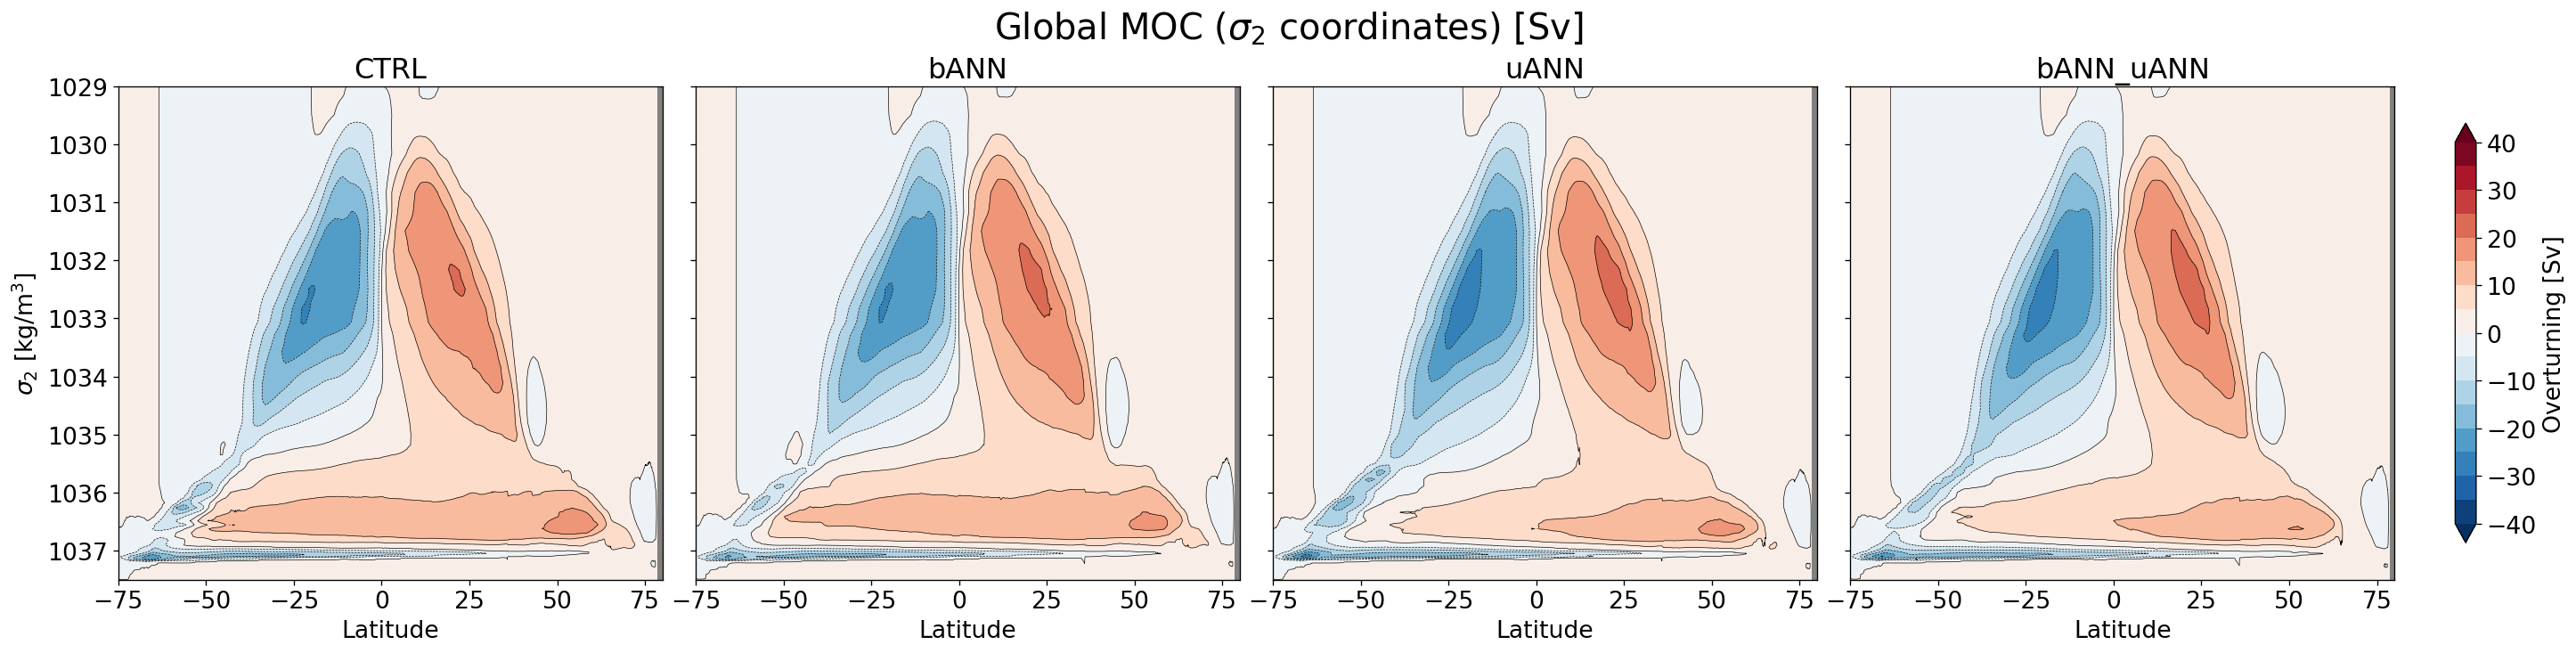

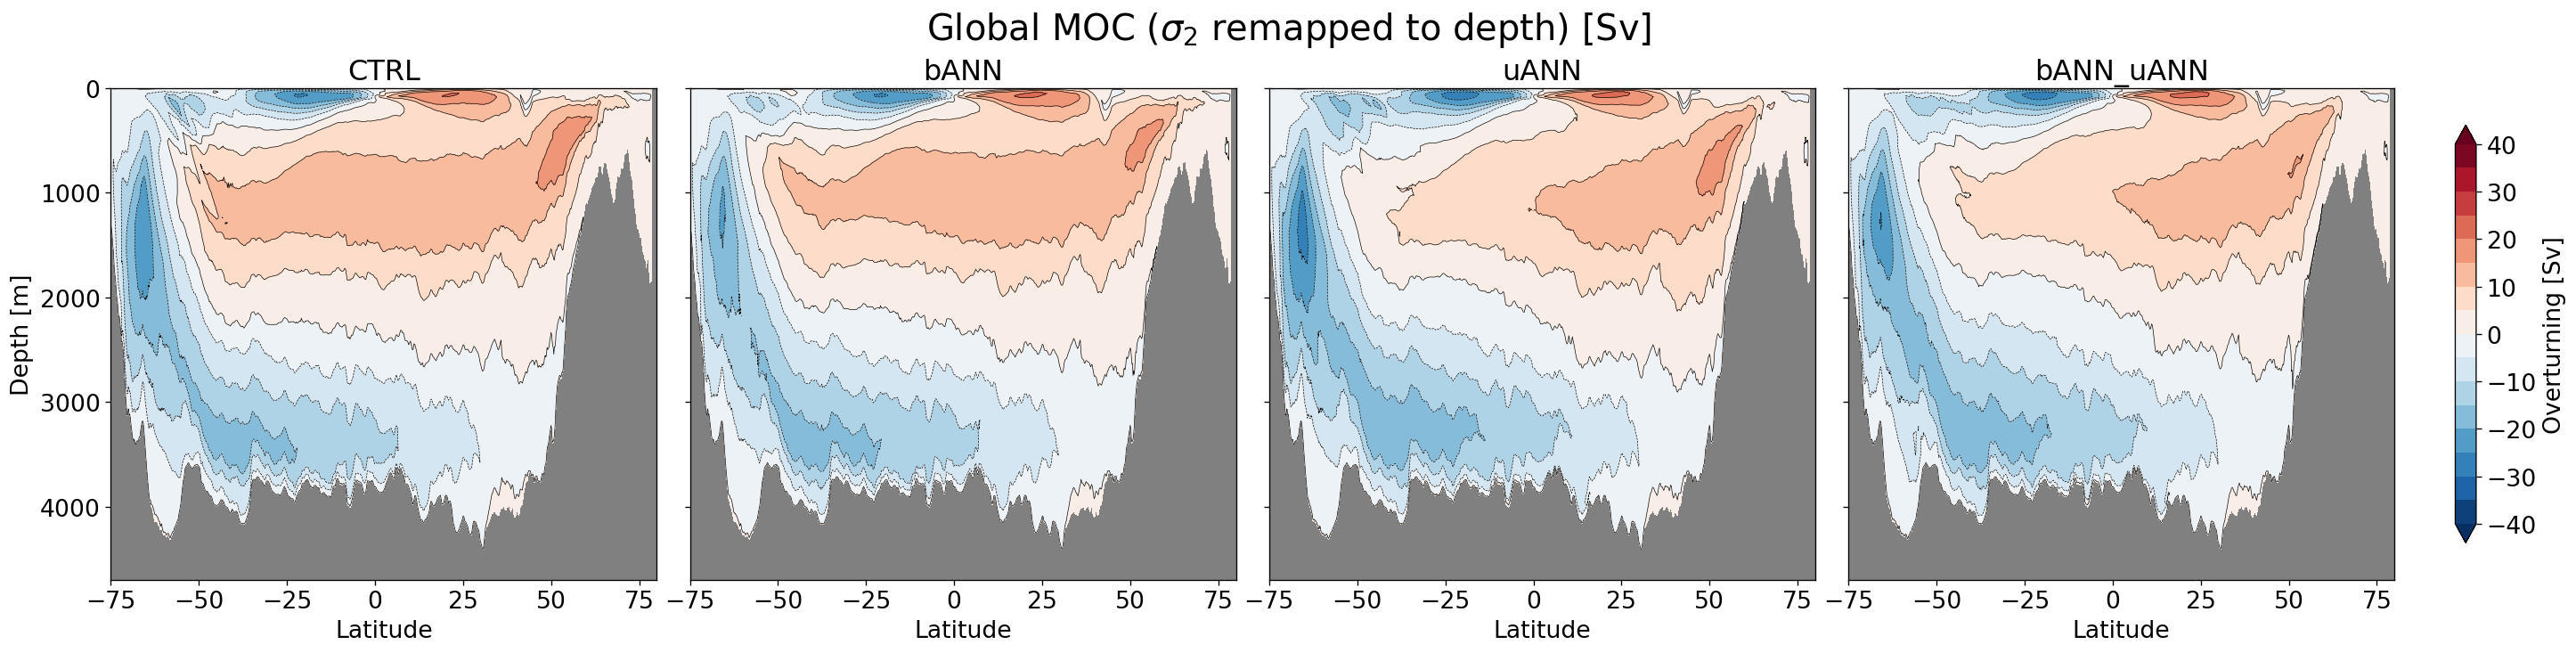

In [4]:
GLOBAL_LEVELS = np.arange(-40, 41, 5)

plot_moc_row(lambda n: exps[n].moc_sigma2()['moc'], 'rho2_l', GLOBAL_LEVELS,
            SIGMA2_YLIM, r'$\sigma_2$ [kg/m$^3$]', 'Overturning',
            r'Global MOC ($\sigma_2$ coordinates) [Sv]')
plot_moc_row(lambda n: exps[n].moc_sigma2()['moc'], 'moc_depth', GLOBAL_LEVELS,
            DEPTH_YLIM, 'Depth [m]', 'Overturning',
            r'Global MOC ($\sigma_2$ remapped to depth) [Sv]')

# 2. Submesoscale (mixed-layer-eddy) overturning

`moc_FFH`, the `vhml`-based contribution (Fox-Kemper/FFH mixed-layer
restratification). Genuinely computed from real GFDL output, not a
placeholder -- shown on a much tighter Sv scale than the total, since this
component is a small correction to it.

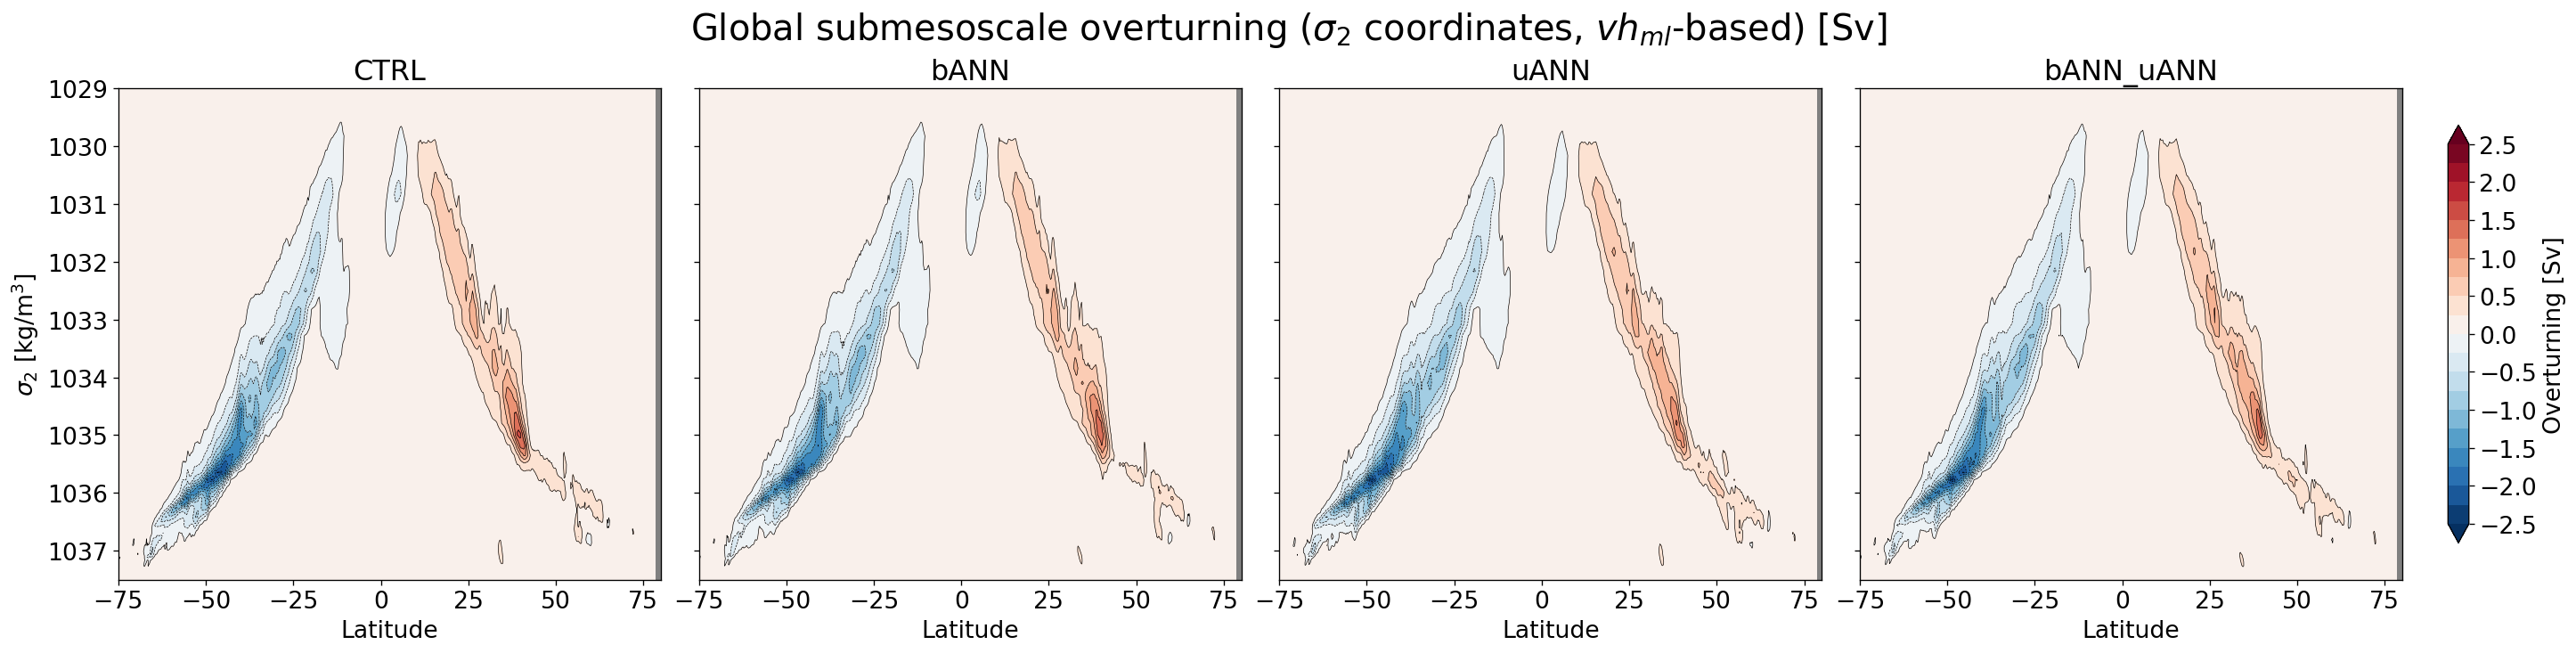

In [5]:
FFH_LEVELS = np.arange(-2.5, 2.6, 0.25)

plot_moc_row(lambda n: exps[n].moc_sigma2()['moc_FFH'], 'rho2_l', FFH_LEVELS,
            SIGMA2_YLIM, r'$\sigma_2$ [kg/m$^3$]', 'Overturning',
            r'Global submesoscale overturning ($\sigma_2$ coordinates, $vh_{ml}$-based) [Sv]')

# 3. GM (mesoscale) overturning -- unavailable, shown as zero

**`moc_GM` is not real data.** GFDL's `diag_table` never saved `vhGM` (the
Gent-McWilliams thickness-diffusion bolus transport), so `mom6_tools`'s own
built-in fallback (zero-fill any missing transport variable) makes this
component identically zero everywhere -- the near-uniform value below reflects
the script's own `+0.1` plotting-offset convention applied to an all-zero
field, not a real (near-zero) GM contribution. Shown only for schema
completeness/transparency, so a reader comparing this notebook against
`key_diagnostics.ipynb`'s CESM GM panels knows exactly why GFDL's looks
featureless.

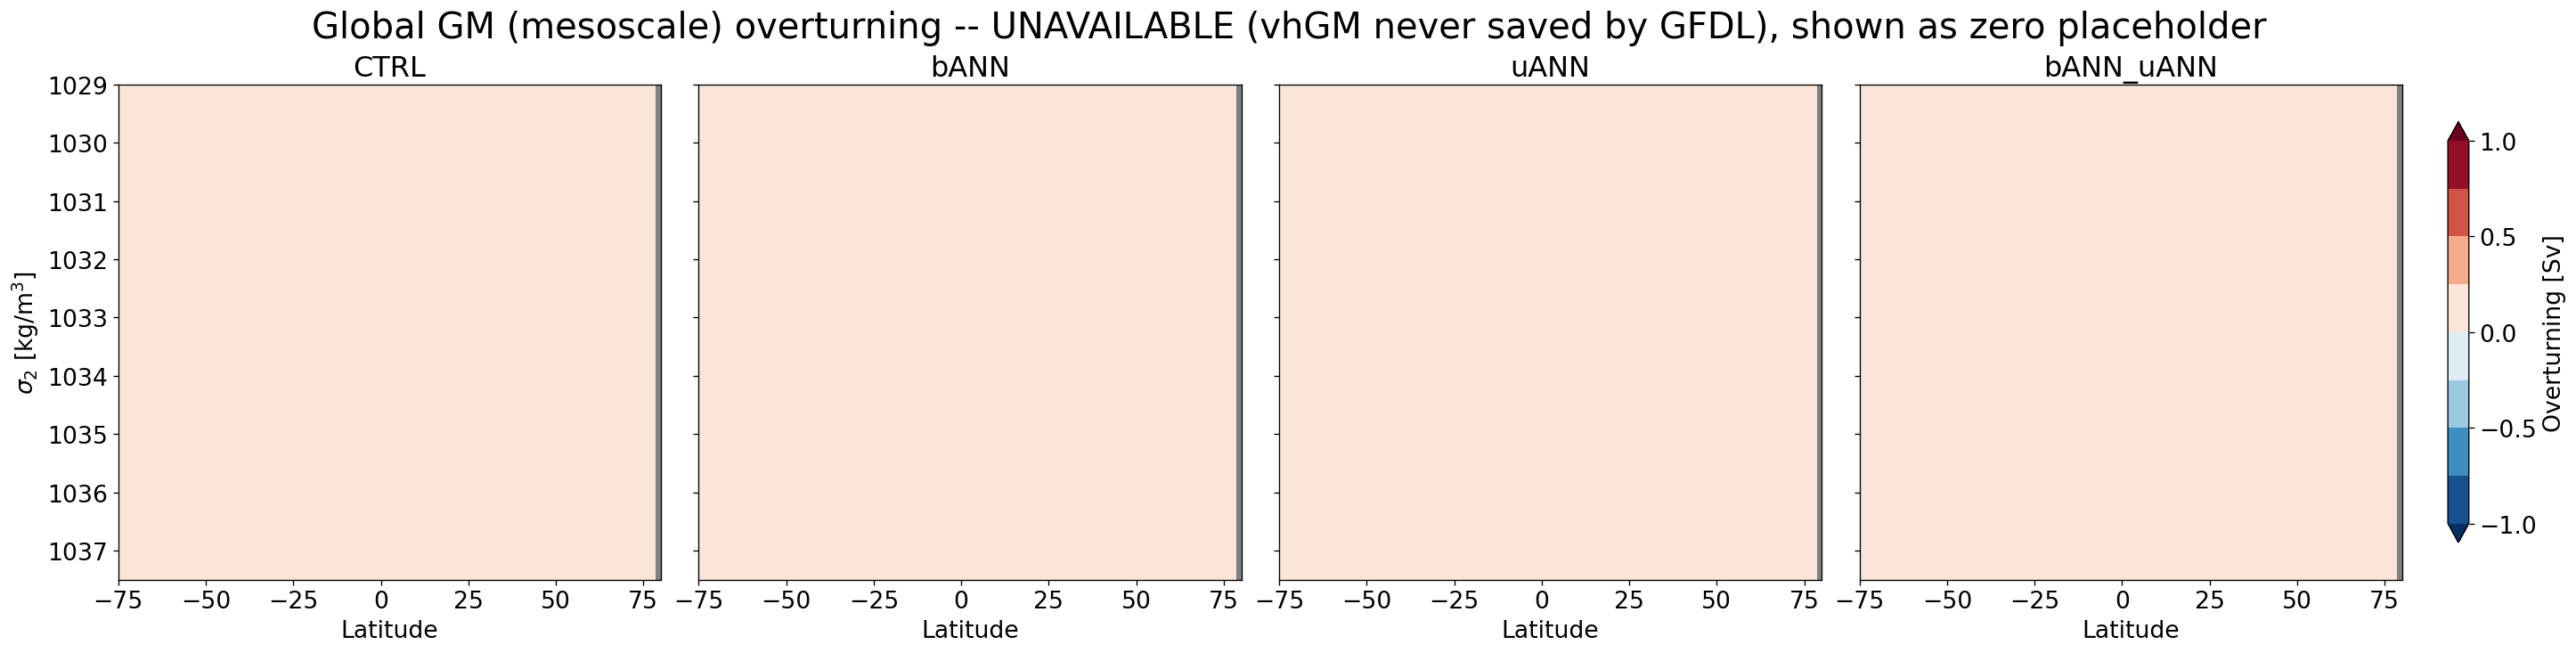

In [6]:
GM_LEVELS = np.linspace(-1, 1, 9)

plot_moc_row(lambda n: exps[n].moc_sigma2()['moc_GM'], 'rho2_l', GM_LEVELS,
            SIGMA2_YLIM, r'$\sigma_2$ [kg/m$^3$]', 'Overturning',
            r'Global GM (mesoscale) overturning -- UNAVAILABLE (vhGM never saved by GFDL), shown as zero placeholder')

# 4. AMOC (Atlantic overturning)

Atlantic-basin decomposition (Atlantic + Arctic + Hudson Bay + Med + Black
Sea codes) via `mom6_tools.m6toolbox.genBasinMasks` on GFDL's native grid --
see the introduction above for how this was validated. Shows a NADW-type
cell peaking in the northern mid-latitudes.

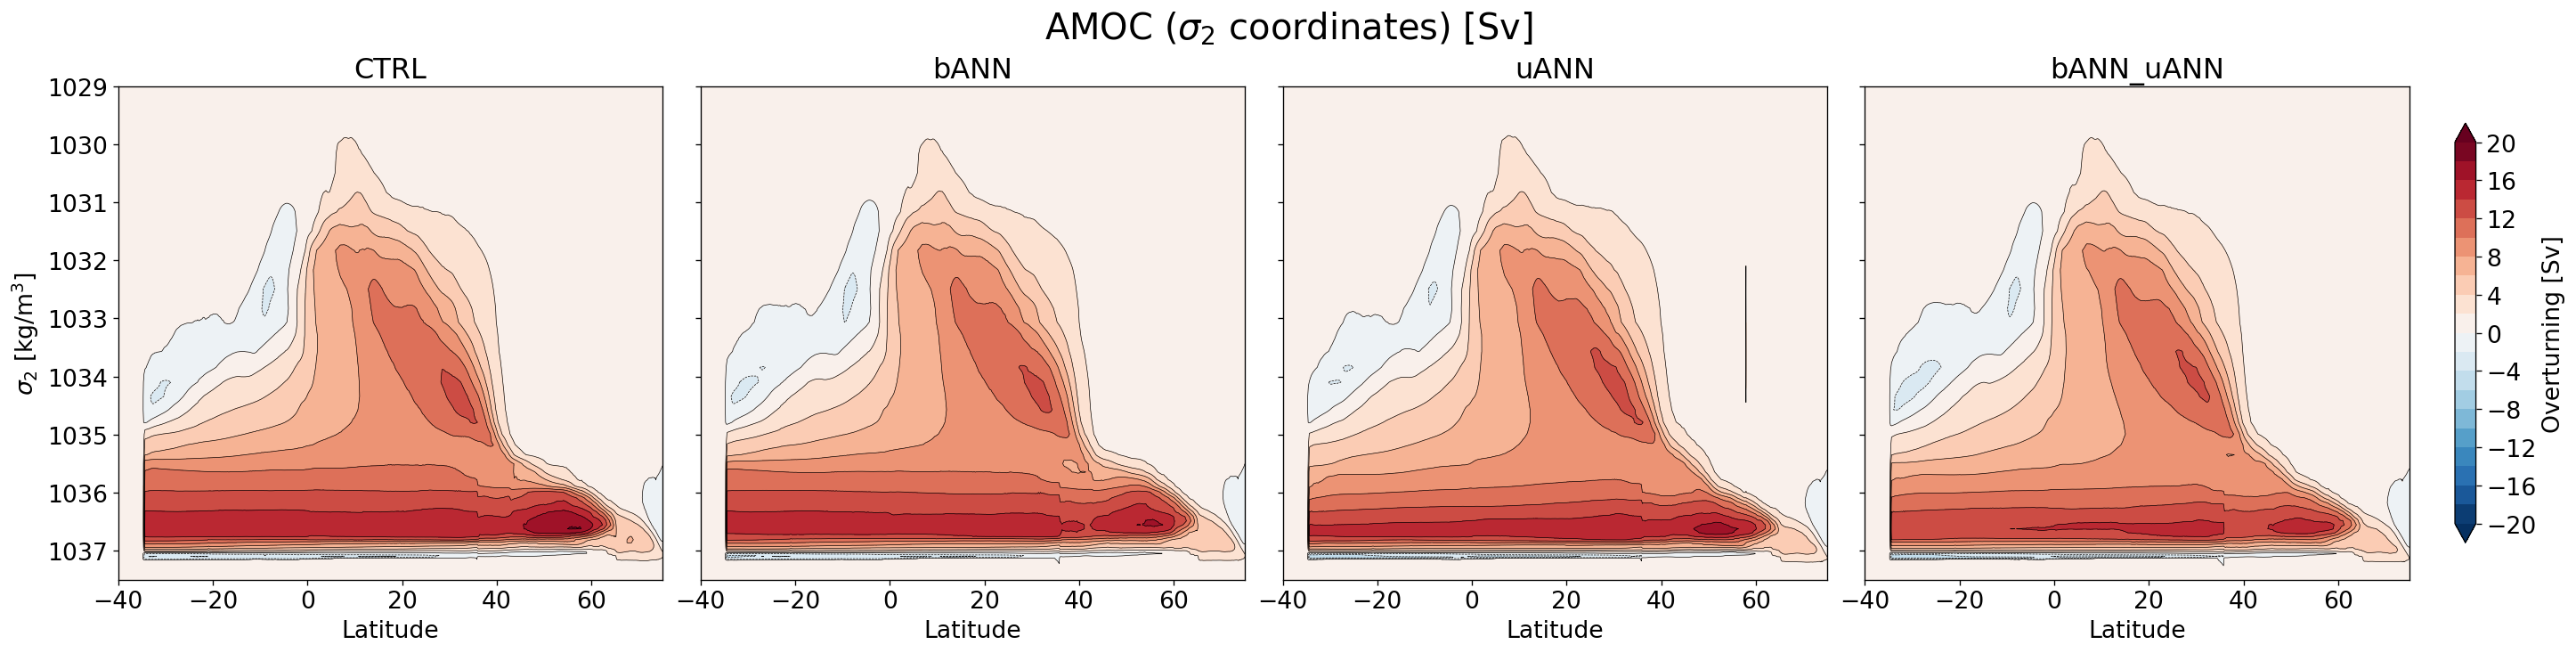

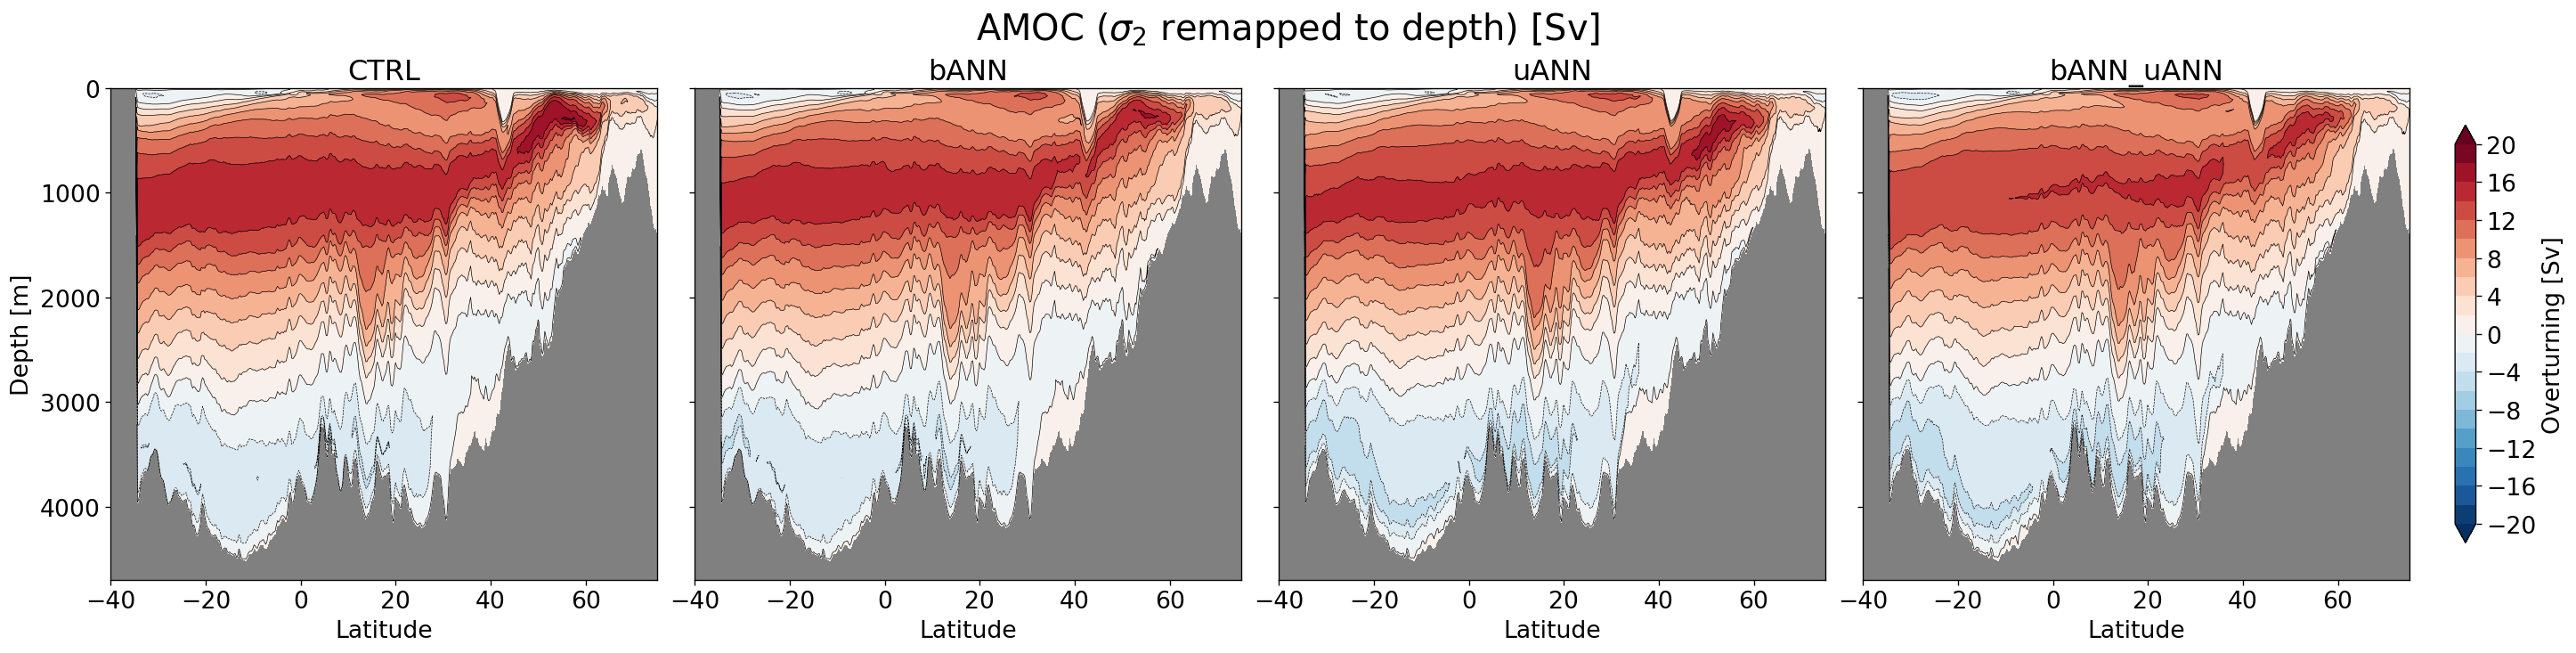

In [7]:
AMOC_LEVELS = np.arange(-20, 22, 2)

plot_moc_row(lambda n: exps[n].moc_sigma2()['amoc'], 'rho2_l', AMOC_LEVELS,
            SIGMA2_YLIM, r'$\sigma_2$ [kg/m$^3$]', 'Overturning',
            r'AMOC ($\sigma_2$ coordinates) [Sv]', xlim=ATL_XLIM)
plot_moc_row(lambda n: exps[n].moc_sigma2()['amoc'], 'amoc_depth', AMOC_LEVELS,
            DEPTH_YLIM, 'Depth [m]', 'Overturning',
            r'AMOC ($\sigma_2$ remapped to depth) [Sv]', xlim=ATL_XLIM)

# 5. Indo-Pacific overturning (IPMOC)

Indo-Pacific basin decomposition (everything outside the Atlantic mask above)
via the same `genBasinMasks` output. Dominated by wind-driven
subtropical/equatorial cells, concentrated at lower latitudes than the
Atlantic cell.

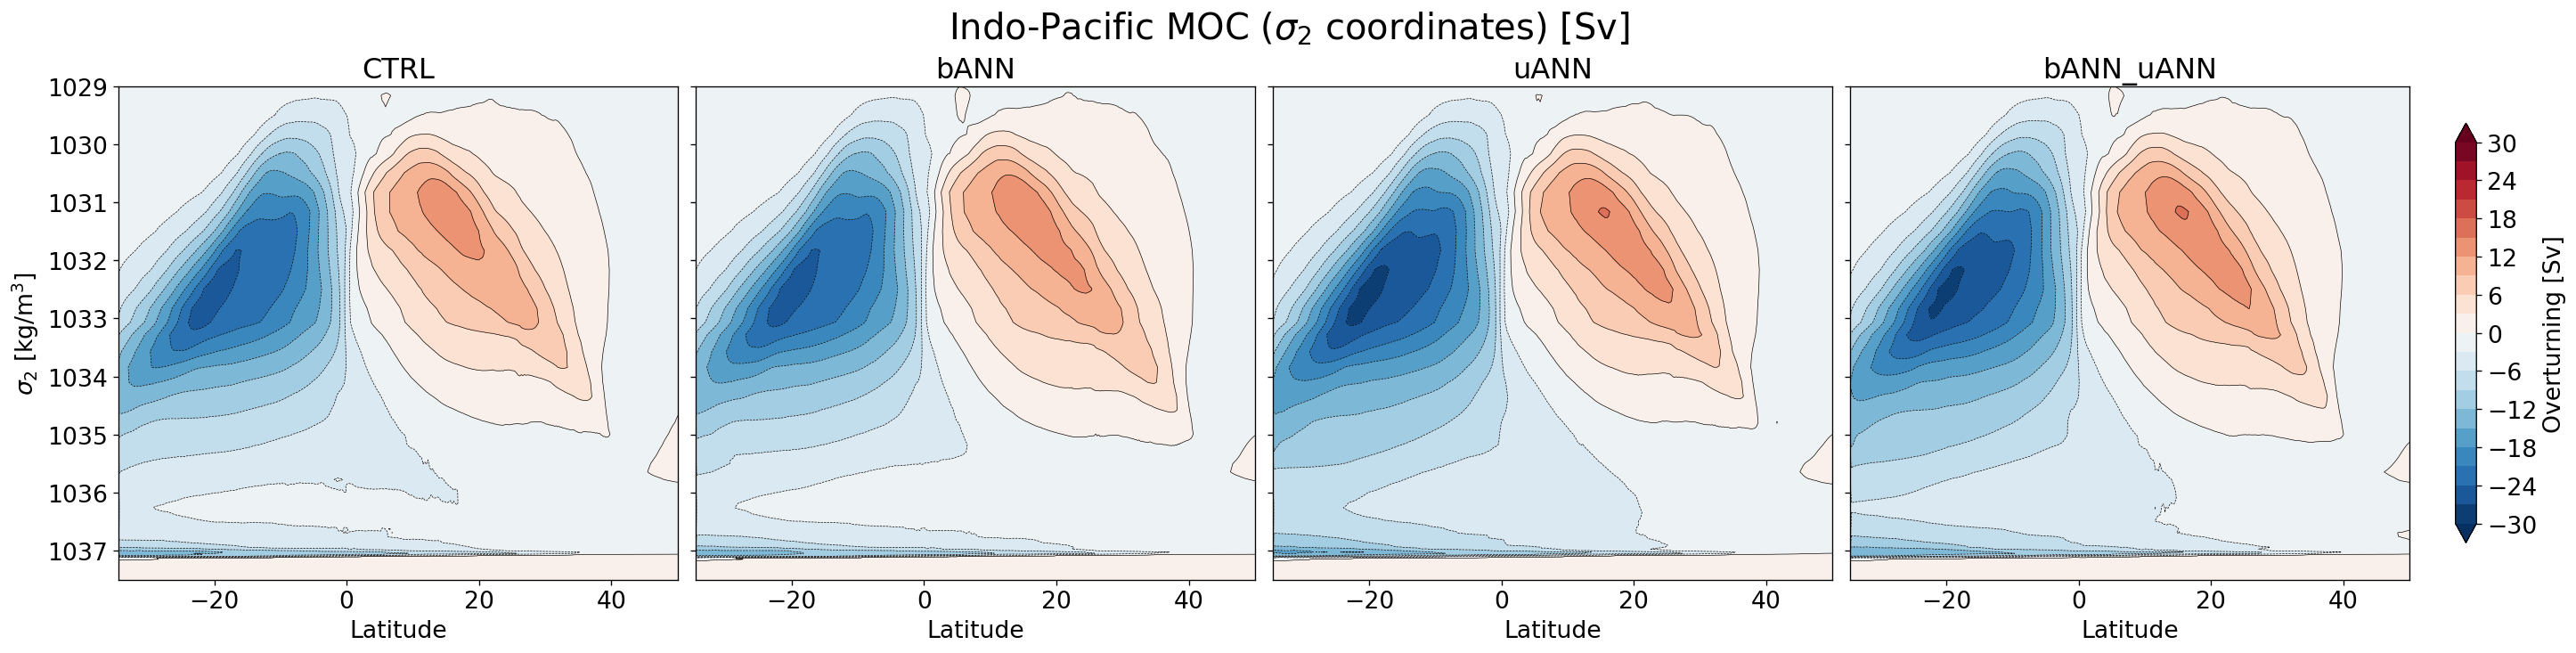

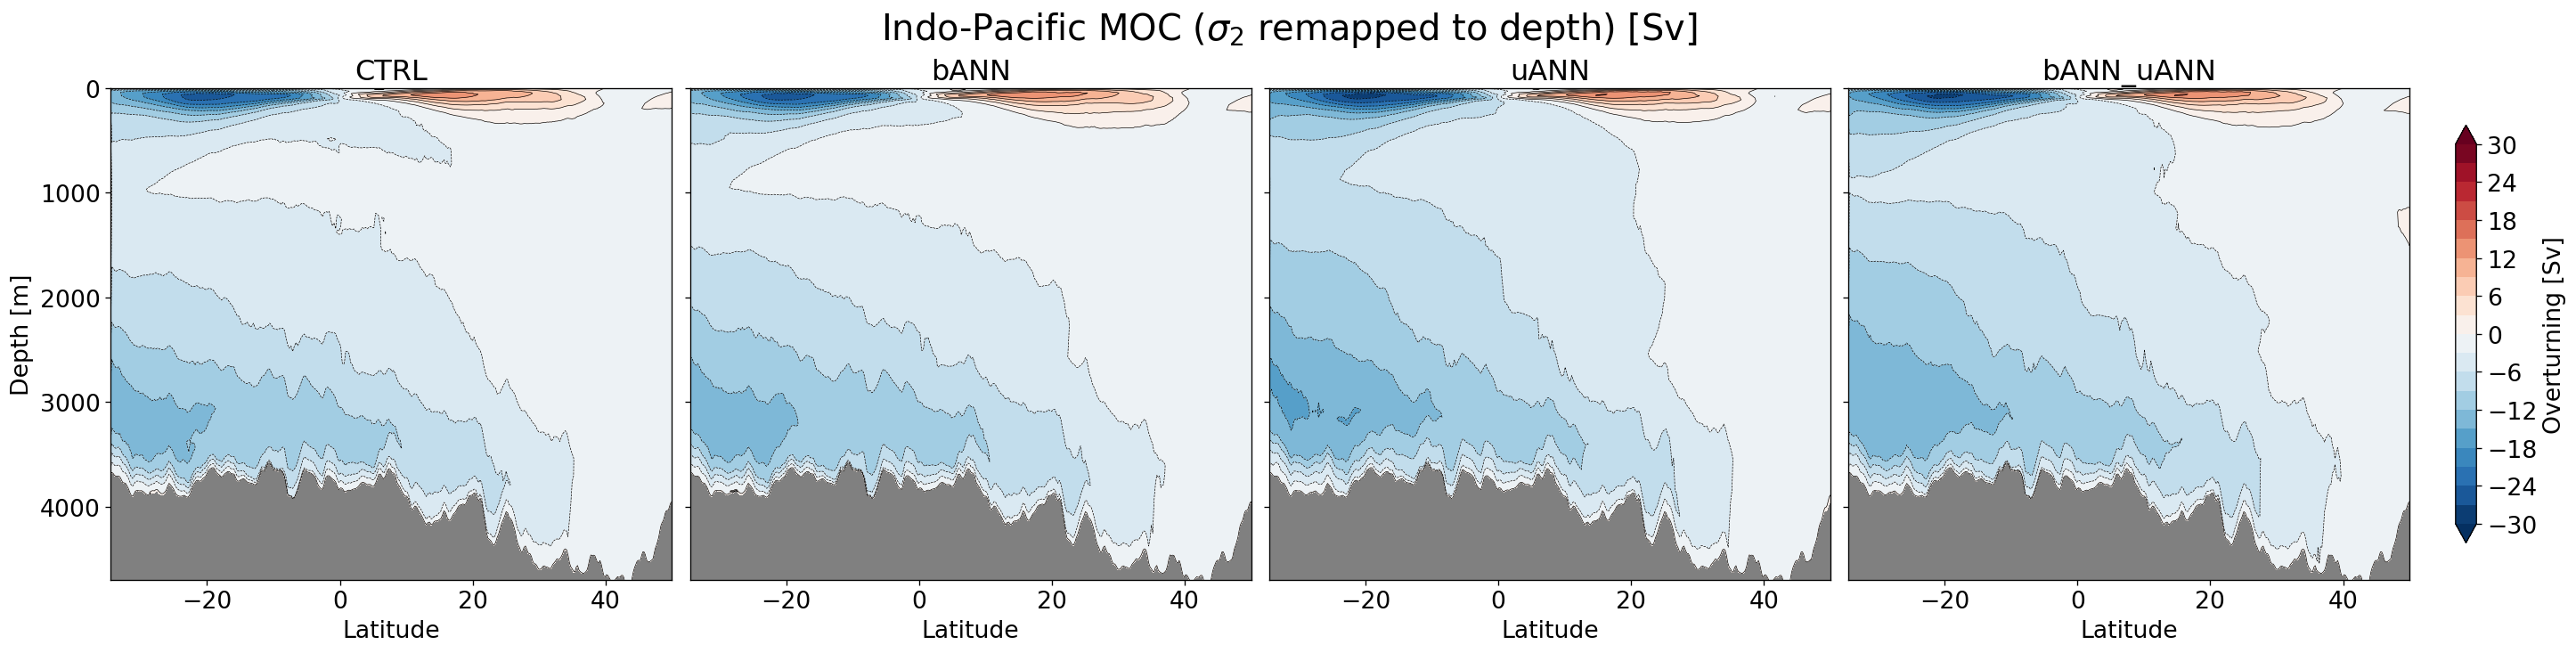

In [8]:
IPMOC_LEVELS = np.arange(-30, 33, 3)

plot_moc_row(lambda n: exps[n].moc_sigma2()['ipmoc'], 'rho2_l', IPMOC_LEVELS,
            SIGMA2_YLIM, r'$\sigma_2$ [kg/m$^3$]', 'Overturning',
            r'Indo-Pacific MOC ($\sigma_2$ coordinates) [Sv]', xlim=IP_XLIM)
plot_moc_row(lambda n: exps[n].moc_sigma2()['ipmoc'], 'ipmoc_depth', IPMOC_LEVELS,
            DEPTH_YLIM, 'Depth [m]', 'Overturning',
            r'Indo-Pacific MOC ($\sigma_2$ remapped to depth) [Sv]', xlim=IP_XLIM)

# 6. Poleward ocean heat transport (advective only)

Time-mean poleward ocean heat transport vs latitude, from
`mom6_tools.poleward_heat_transport`. **This is advective-only, not the full
transport CESM's own notebooks show.**

- `mom6_tools.poleward_heat_transport` needs three vertically-integrated
  meridional flux terms: `T_ady_2d` (advective), `T_diffy_2d` (isopycnal
  diffusion), `T_hbd_diffy_2d` (horizontal boundary-layer diffusion). GFDL's
  `diag_table` only ever saved the advective one, and only in 3D (`T_ady`,
  split across 35 `z_l` levels) rather than CESM's already-vertically-summed
  2D field. `gfdl_shim_heat_transport.py` reconstructs `T_ady_2d` via
  `T_ady.sum(dim='z_l')` -- a real computation on real data (GFDL's own
  `ocean_annual_z` stream), matching that field's own `cell_methods='z_l:sum'`
  attribute, not a fabrication. `T_diffy_2d`/`T_hbd_diffy_2d` are genuinely
  absent -- nothing in GFDL's output is a directional (y-component) transport
  flux for either (there are local heating-rate *tendencies* like
  `opottempdiff`, but reconstructing a flux from a tendency means solving an
  inverse problem, which this does not attempt).
- `mom6_tools.poleward_heat_transport`'s own preprocessing step zero-fills
  any missing variable unconditionally, so its built-in "diffusive term not
  found" warning never actually fires for GFDL (the zero-filled array
  satisfies its own presence check) -- the model curve below is silently
  missing two of its three physical components. Expect it to sit **below**
  the observational reference curves in magnitude, not on top of them; that
  gap is the missing diffusive + HBD contribution, not a bug.
- Four bugs were found and fixed in the vendored `poleward_heat_transport.py`
  (and, proactively, the closely-related `moc.py`) while preparing this,
  all but one stemming from the same root cause: GFDL's native grid uses
  MOM6's **'outer'** q-point convention (`yq = yh + 1` = 1162), while the
  vendored scripts assumed CESM's **'right'** convention (`yq == yh` = 1161)
  everywhere -- in the zero-fill fallback's coordinates and shape, and in two
  places that multiply a `yh`-sized basin mask against `yq`-sized transport
  data via a `yh`-to-`yq` rename that silently assumed equal lengths. The
  fourth (unrelated) bug was a missing `.units` attribute on the zero-fill
  placeholder that later code read unconditionally.

Latitude axis and basin mask follow the vendored script's own conventions
(`geolat_c` corner latitudes; Atlantic = basin codes 2/4/6/7/8, from GFDL's
own native `basin` field, extended from `yh` to `yq` the same way as the
script-level fixes above). JRA-55(do) is overlaid as a reference, not a
target -- given the missing components, the model curve is expected to fall
inside/below its envelope, not match it.

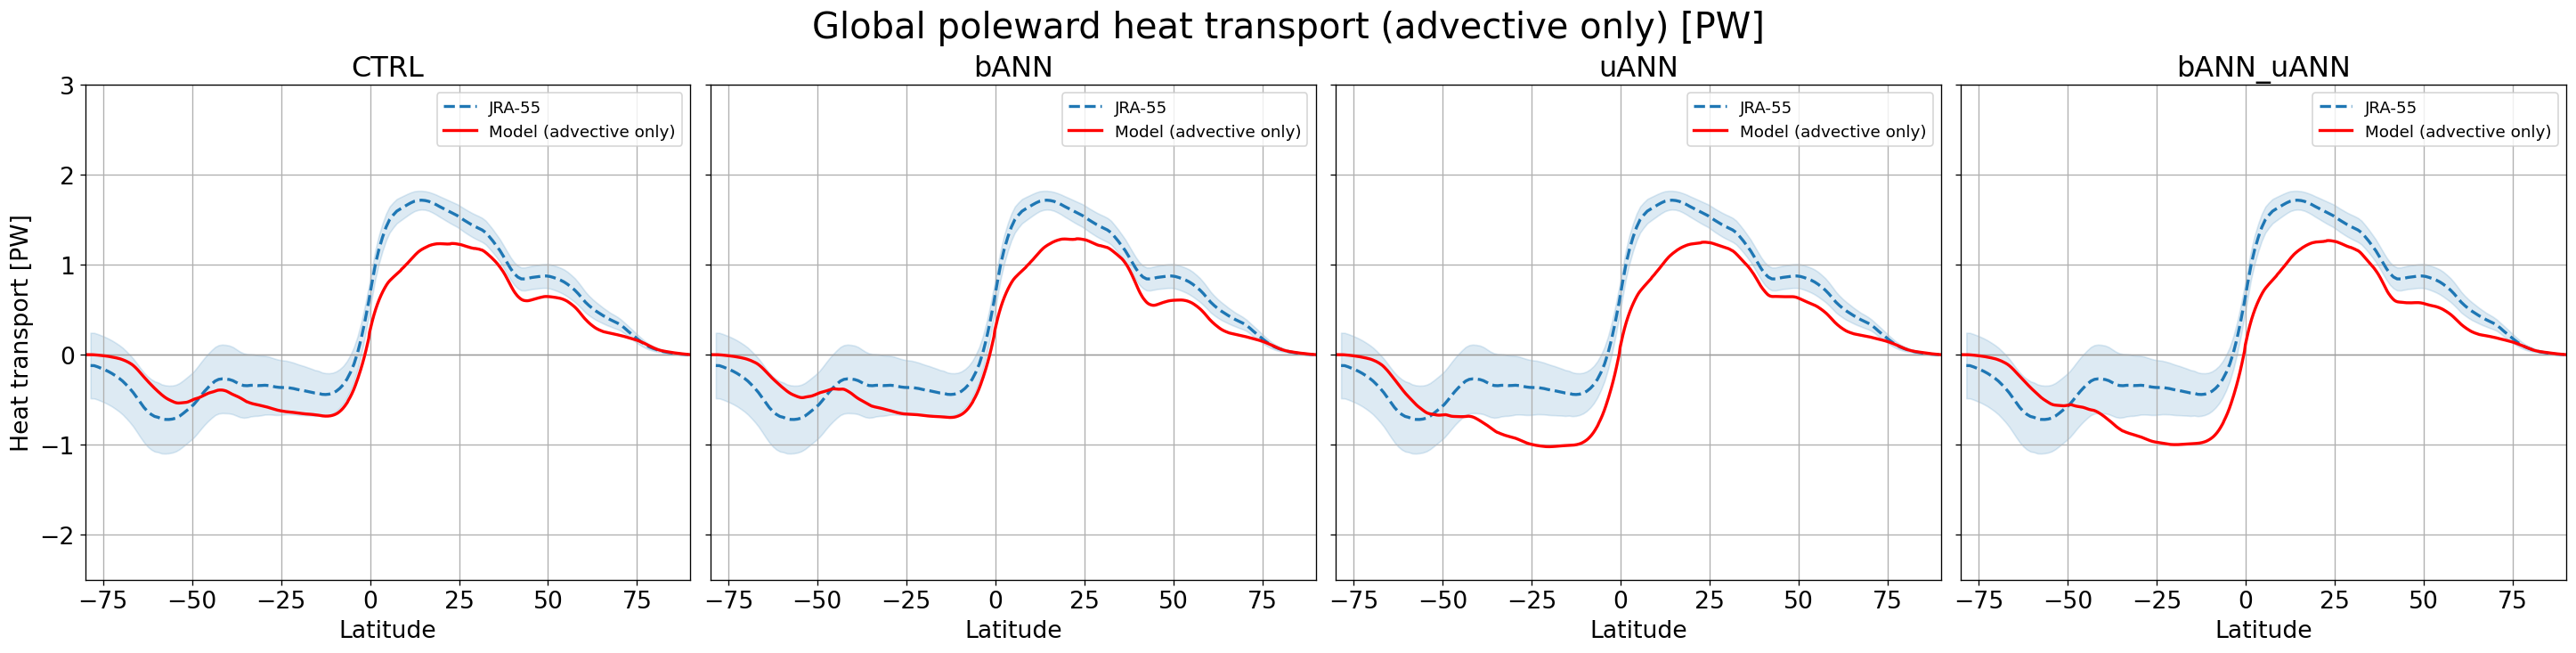

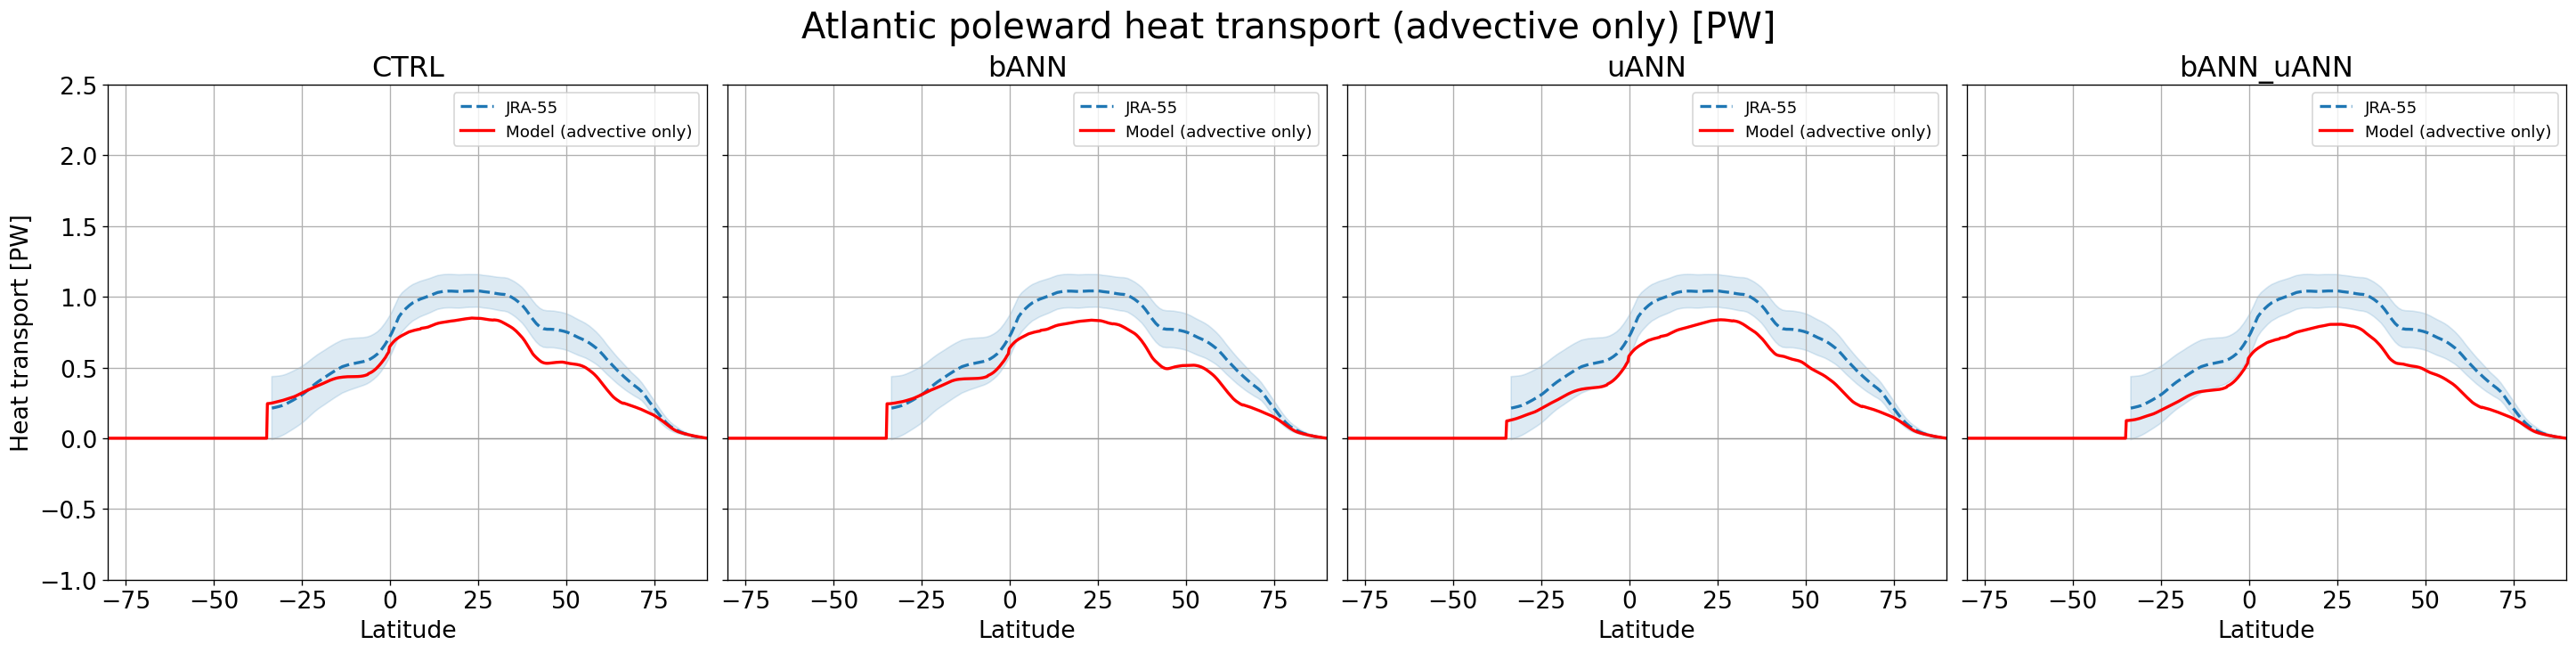

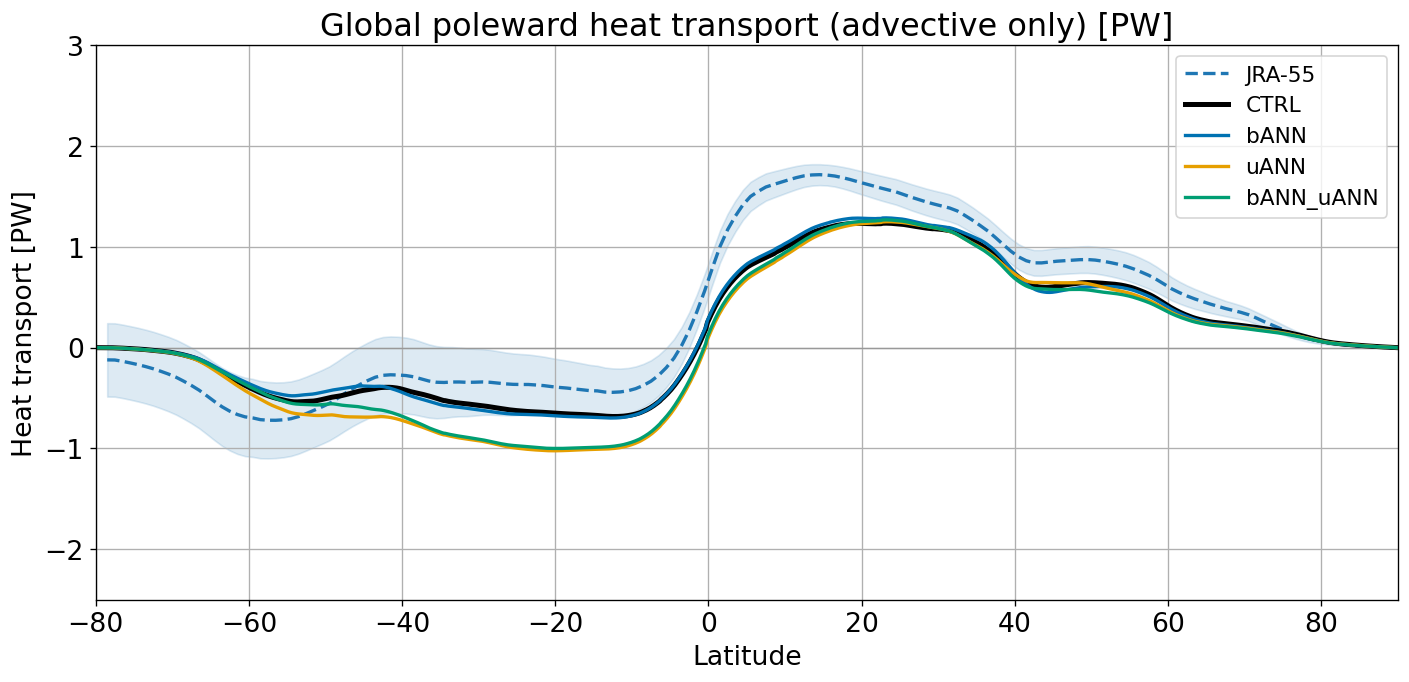

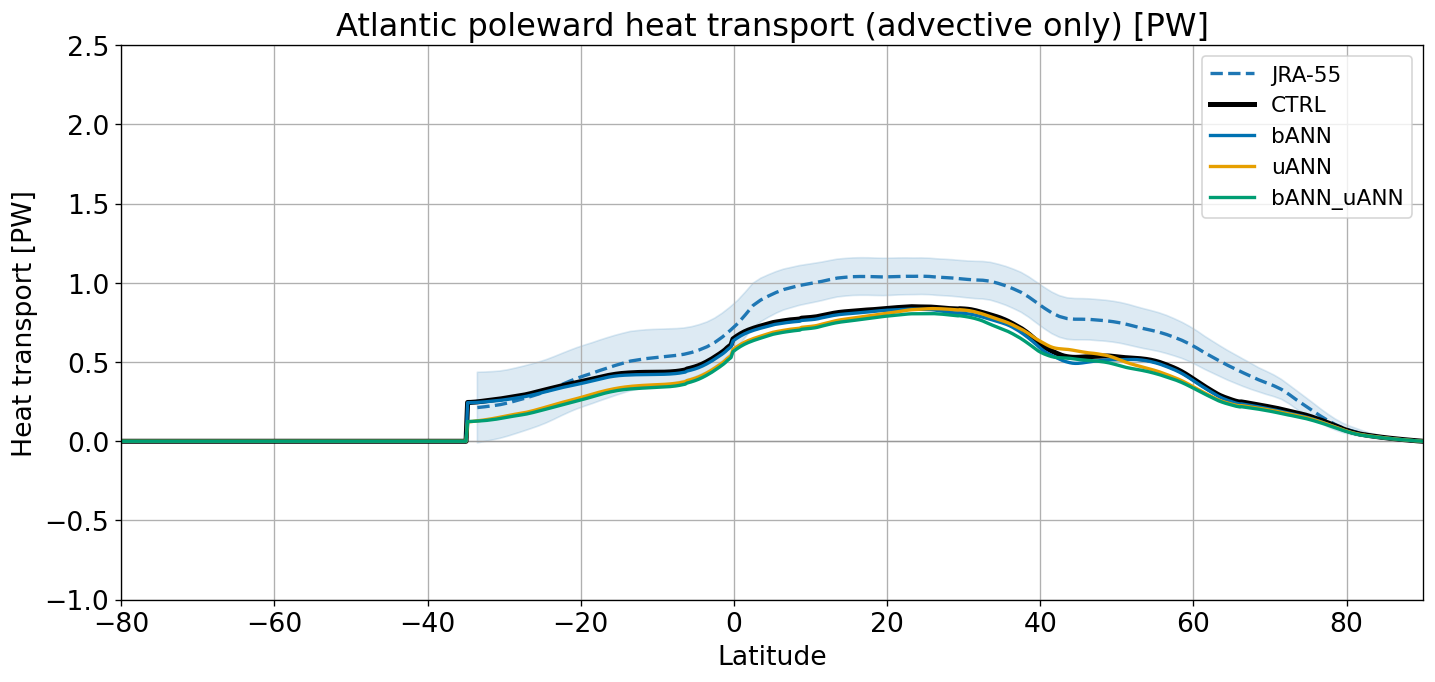

In [9]:
PW = 1.0e15  # 1 petawatt in watts

COLORS = {
    'gfdl_CTRL_moc':      'k',
    'gfdl_bANN_moc':      '#0072B2',
    'gfdl_uANN_moc':      '#E69F00',
    'gfdl_bANN_uANN_moc': '#009E73',
}

jra = xr.open_dataset('/glade/work/gmarques/cesm/datasets/Heat_transport/'
                      'jra55fcst_v1_3_annual_1x1/nht_jra55do_v1_3.nc')
JRA_BASIN = {'global': 0, 'atlantic': 1}


def _add_jra_baseline(ax, basin):
    nht = jra.nht.isel(basin=JRA_BASIN[basin])
    jra_mean = nht.mean('time')
    jra_std = nht.std('time')
    ax.plot(jra.lat, jra_mean, color='tab:blue', ls='--', lw=2, label='JRA-55')
    ax.fill_between(jra.lat, jra_mean - jra_std, jra_mean + jra_std,
                    color='tab:blue', alpha=0.15)


def _atlantic_mask_yq(exp):
    """Atlantic-basin mask (codes 2/4/6/7/8, matching
    poleward_heat_transport.py's own convention) on the yq (face-point)
    grid, from GFDL's own native basin field (yh-sized) extended by one row
    to match yq -- same fix applied to the vendored moc.py/
    poleward_heat_transport.py this session, since GFDL's native grid uses
    MOM6's 'outer' q-point convention (yq = yh+1)."""
    basin = np.round(exp.grd.basin.values)
    atl = np.isin(basin, [2, 4, 6, 7, 8]).astype(float)
    if atl.shape[0] != exp.grd.sizes['yq']:
        atl = np.concatenate([atl, atl[-1:, :]], axis=0)
    return atl


def _heat_transport_pw(name, mask_fn):
    """Poleward heat transport [PW] vs latitude for one experiment."""
    exp = exps[name]
    lat = exp.grd.geolat_c.max(dim='xq').values
    ht = exp.heat_transport()  # raw W, (yq, xh)
    if mask_fn is not None:
        ht = ht * mask_fn(exp)
    return lat, ht.sum(dim='xh').values / PW


def plot_heat_transport_row(mask_fn, jra_basin, ylim, suptitle):
    """1x4 row of poleward heat-transport curves (model only, advective-only
    for GFDL -- see markdown above) vs latitude."""
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    for col, name in enumerate(names):
        ax = axes[col]
        lat, ht_pw = _heat_transport_pw(name, mask_fn)
        _add_jra_baseline(ax, jra_basin)
        ax.axhline(0, color='0.6', lw=0.8)
        ax.plot(lat, ht_pw, 'r', lw=2, label='Model (advective only)')
        ax.set_xlim(-80, 90)
        ax.set_ylim(ylim)
        ax.set_title(LABELS[name])
        ax.set_xlabel('Latitude')
        ax.grid(True)
        if col == 0:
            ax.set_ylabel('Heat transport [PW]')
        ax.legend(fontsize=11)
    fig.suptitle(suptitle, fontsize=24)
    plt.show()


def plot_heat_transport_lines(mask_fn, jra_basin, ylim, title):
    """All 4 experiments overlaid as lines on one axes (CTRL in black)."""
    fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
    _add_jra_baseline(ax, jra_basin)
    ax.axhline(0, color='0.6', lw=0.8)
    for name in names:
        lat, ht_pw = _heat_transport_pw(name, mask_fn)
        is_ctrl = name == CTRL
        ax.plot(lat, ht_pw, lw=3 if is_ctrl else 2, color=COLORS[name], label=LABELS[name])
    ax.set_xlim(-80, 90)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Heat transport [PW]')
    ax.grid(True)
    ax.legend(loc='best', fontsize=13)
    plt.show()


plot_heat_transport_row(None, 'global', (-2.5, 3.0),
                        'Global poleward heat transport (advective only) [PW]')
plot_heat_transport_row(_atlantic_mask_yq, 'atlantic', (-1.0, 2.5),
                        'Atlantic poleward heat transport (advective only) [PW]')

plot_heat_transport_lines(None, 'global', (-2.5, 3.0),
                         'Global poleward heat transport (advective only) [PW]')
plot_heat_transport_lines(_atlantic_mask_yq, 'atlantic', (-1.0, 2.5),
                         'Atlantic poleward heat transport (advective only) [PW]')

# 7. Global MOC/AMOC/IPMOC in z (depth) coordinates, with a real AMOC time series

Unlike Sections 1-5 (density/$\sigma_2$-space, from the native
`ocean_annual_rho2` stream), this section uses **real depth-coordinate**
`vmo`/`vhml`/`vo` from GFDL's `ocean_annual_z` stream -- a native-grid,
z-coordinate transport stream that didn't exist in GFDL's postprocessing
until partway through this session (unlike `ocean_monthly_z_1x1deg`, which
is regridded and has no transport variables at all). This makes
`mom6_tools.moc` usable for GFDL for the first time, and with it a
genuine **annual AMOC-26N/45N time series** -- `mom6_tools.moc_sigma2`
(Sections 1-5) only ever produces a single time-mean snapshot; this is the
first true GFDL overturning time series.

- **`moc`/`amoc`/`ipmoc` here are the full residual-mean transport**, not
  split into an explicit submesoscale-only component the way Section 1-5's
  `moc`/`moc_FFH` are: MOM6's `vmo` is already the residual-mean velocity
  (Eulerian mean + GM bolus + mixed-layer-eddy bolus, per its own transport
  formulation), so `amoc` here implicitly includes GM/MLE effects. Only
  `moc_GM` specifically (the *isolated* GM-only component, needing `vhGM`
  directly) is a genuine zero placeholder -- `vhGM` is still absent from
  GFDL's diag_table, same as in Sections 1-5.
- The `yq` coordinate in `*_moc_MOC.nc` is **real latitude** (not a bare
  grid index the way `moc_sigma2`'s output is) -- it comes directly from
  `ocean_annual_z`'s own data files, so no approximation is needed for the
  x-axis here.
- Six bugs were fixed in the vendored `mom6_tools.moc` (and, for one, the
  shared `m6toolbox.get_z`) to get this running on GFDL's grid: the same
  `yq`='outer'-vs-'right' MOM6 grid-convention family as Sections 1/6 (a
  zero-fill coordinate/shape mismatch, three separate `yh`-sized
  basin-mask-vs-`yq`-sized-transport multiplications, and `get_z`'s
  hardcoded center-point output shape), plus a missing catalog entry
  (`yamls/gfdl_*_moc.yaml`'s `oce_cat` now points at the shared NCAR
  catalog, which has the RAPID/CORE2/POP reference datasets `mom6_tools.moc`
  plots against -- our own local catalog only had WOA/MLD entries).

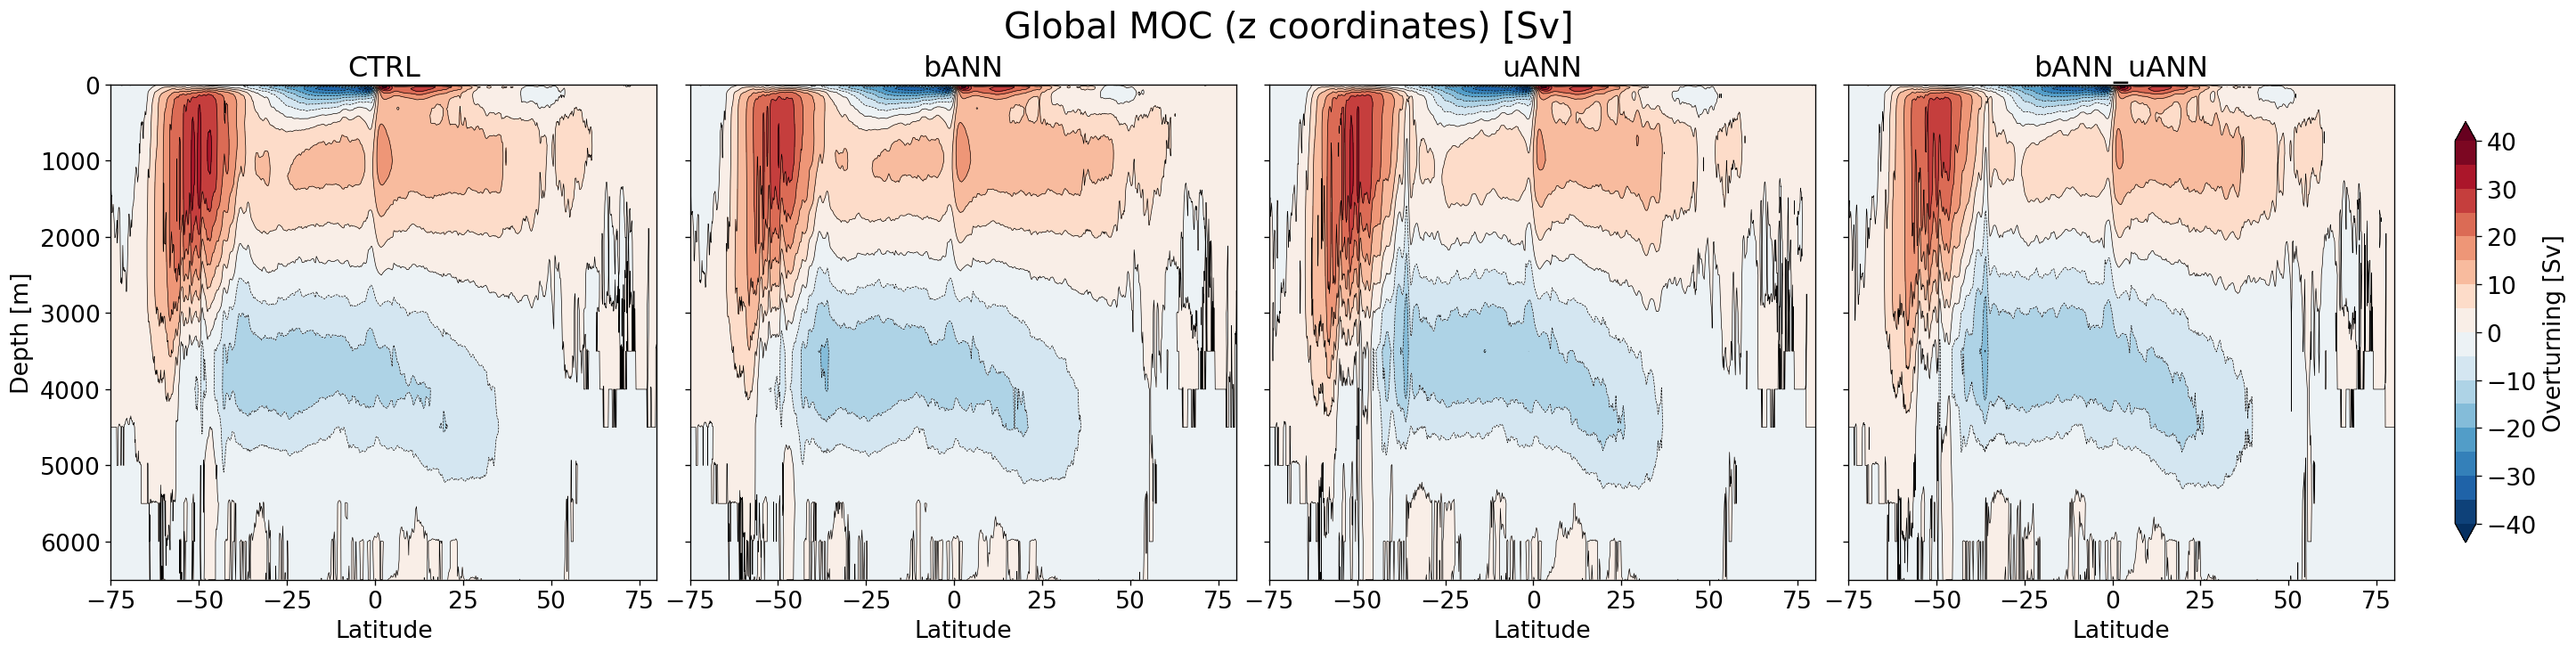

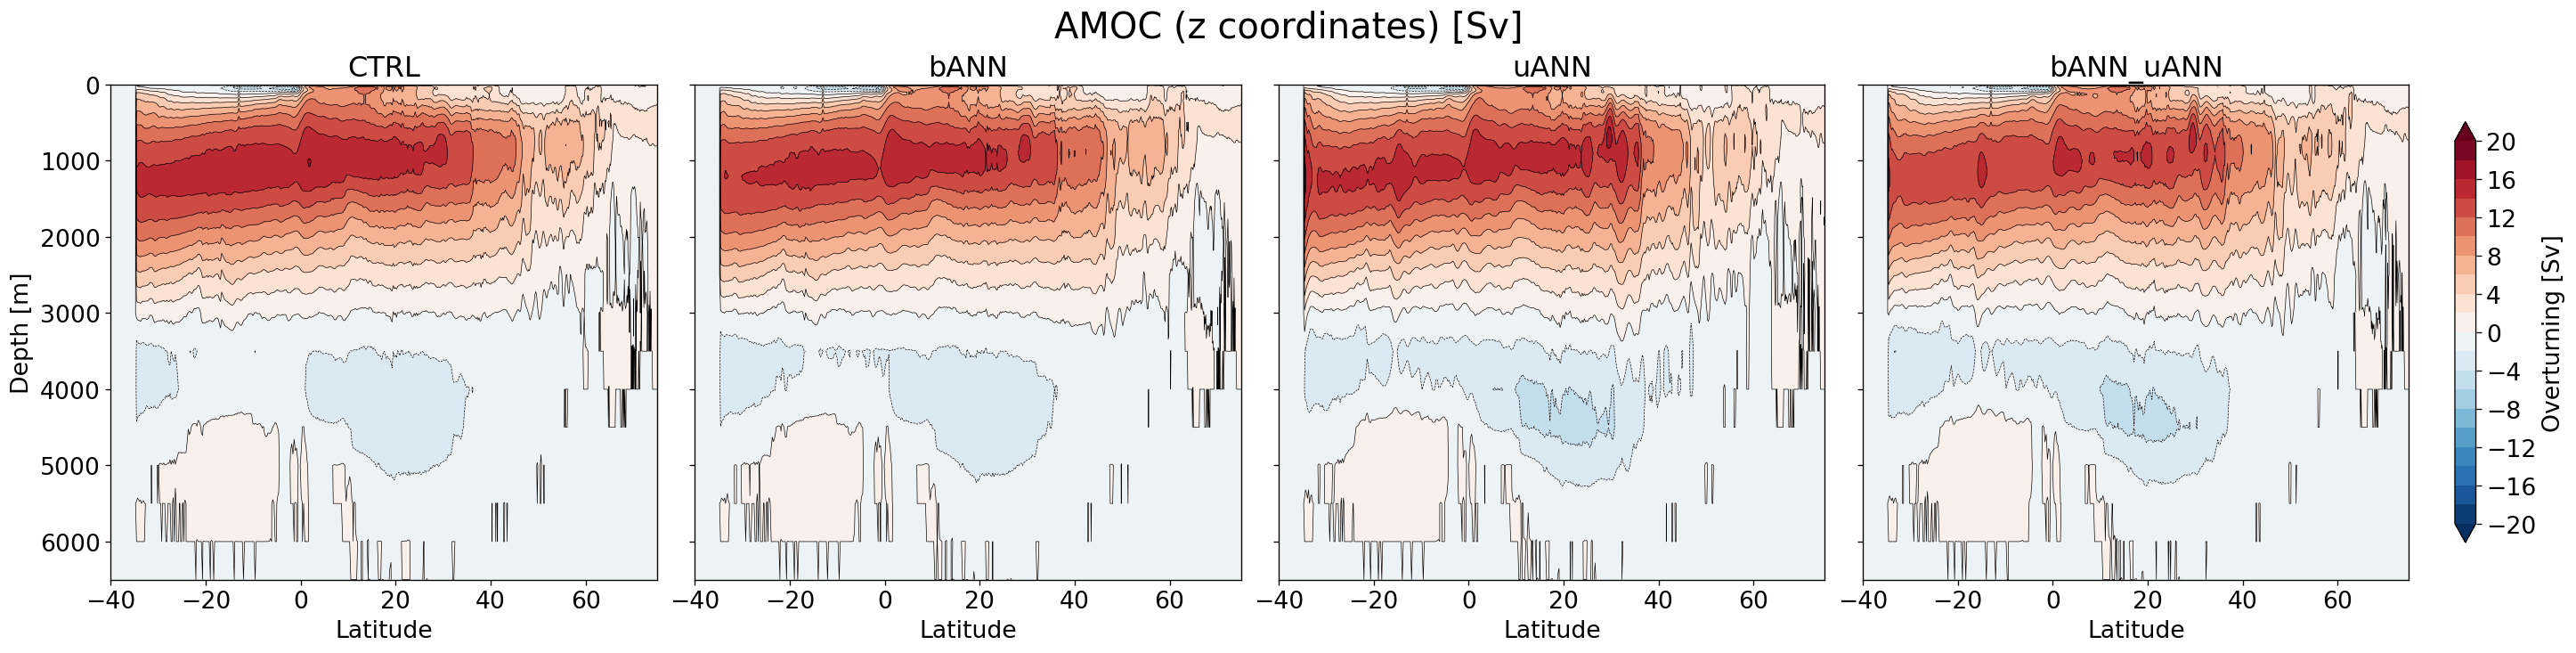

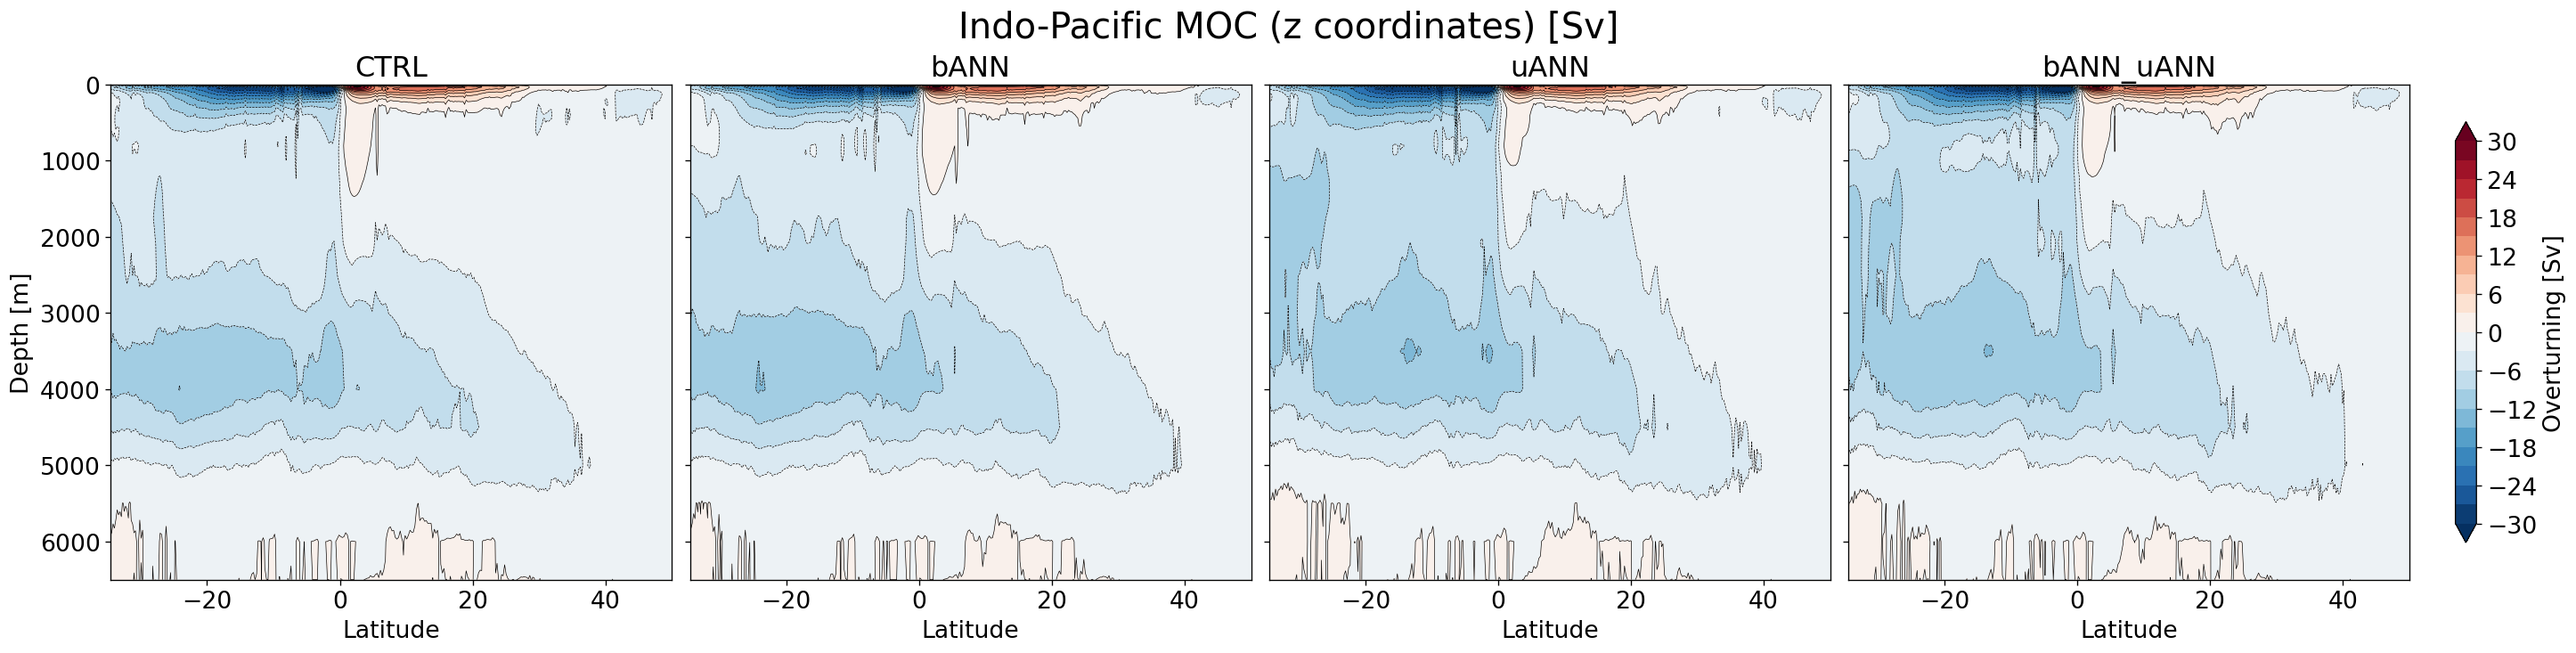

In [10]:
Z_YLIM = (6500, 0)   # m, surface at the top


def plot_moc_z_row(var, levels, xlim, suptitle):
    """1x4 row of z-coordinate overturning-streamfunction panels.

    ``xlim`` follows the vendored moc.py's own basin-specific plot ranges
    (ATL_XLIM/IP_XLIM, defined above) -- outside those bounds the Atlantic/
    Indo-Pacific basin masks genuinely become ambiguous (see plot_moc_row's
    docstring: genBasinMasks has a hardcoded cutting latitude at -34.5,
    confirmed directly by a ~300-cell jump in basin membership in a single
    grid row there), which shows up as a sharp, spurious discontinuity /
    busy contour texture past that range -- also visible in moc.py's own
    saved reference PNGs (PNG/MOC/gfdl_*_moc_MOC_Atlantic.png etc.), which
    are clipped the same way for the same reason.
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    cf = None
    for col, name in enumerate(names):
        ax = axes[col]
        ds = exps[name].moc()
        field = ds[var]
        x = ds['yq'].values
        y = ds['zl'].values
        cf = ax.contourf(x, y, field.values, levels=levels, cmap='RdBu_r', extend='both')
        ax.contour(x, y, field.values, levels=levels, colors='k', linewidths=0.4)
        ax.set_facecolor('gray')
        ax.set_ylim(Z_YLIM)
        ax.set_title(LABELS[name])
        ax.set_xlabel('Latitude')
        ax.set_xlim(xlim)
        if col == 0:
            ax.set_ylabel('Depth [m]')
    cbar = fig.colorbar(cf, ax=axes, label='Overturning [Sv]', extend='both',
                        ticks=levels[::2], shrink=0.85, pad=0.02)
    fig.suptitle(suptitle, fontsize=24)
    plt.show()


Z_GLOBAL_LEVELS = np.arange(-40, 41, 5)
Z_AMOC_LEVELS = np.arange(-20, 22, 2)
Z_IPMOC_LEVELS = np.arange(-30, 33, 3)

plot_moc_z_row('moc', Z_GLOBAL_LEVELS, (-75, 80), 'Global MOC (z coordinates) [Sv]')
plot_moc_z_row('amoc', Z_AMOC_LEVELS, ATL_XLIM, 'AMOC (z coordinates) [Sv]')
plot_moc_z_row('ipmoc', Z_IPMOC_LEVELS, IP_XLIM, 'Indo-Pacific MOC (z coordinates) [Sv]')

## AMOC time series at 26N and 45N

Annual AMOC extremum (max transport below 250 m) at 26.5N (RAPID array
latitude) and 45N, for each experiment's full available record (not just
the 1988-2012 window) -- matching CESM's `key_diagnostics.ipynb` Section 6.

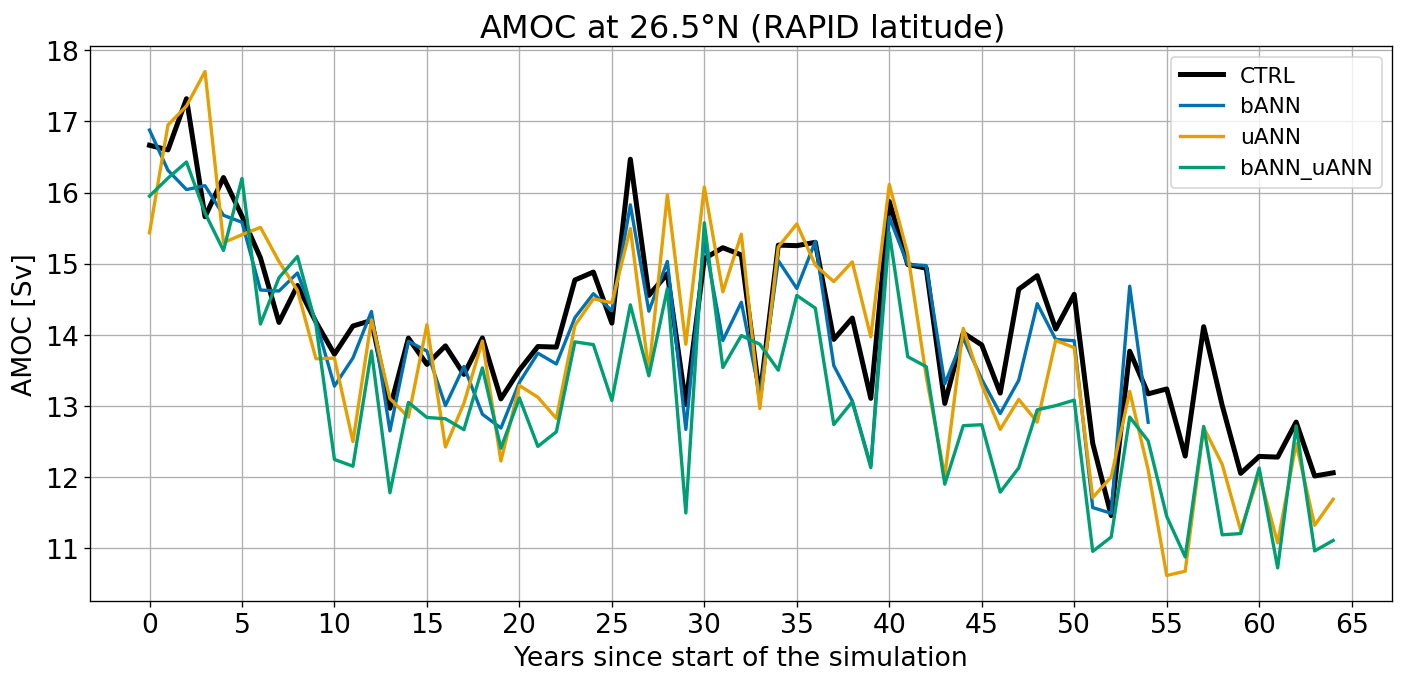

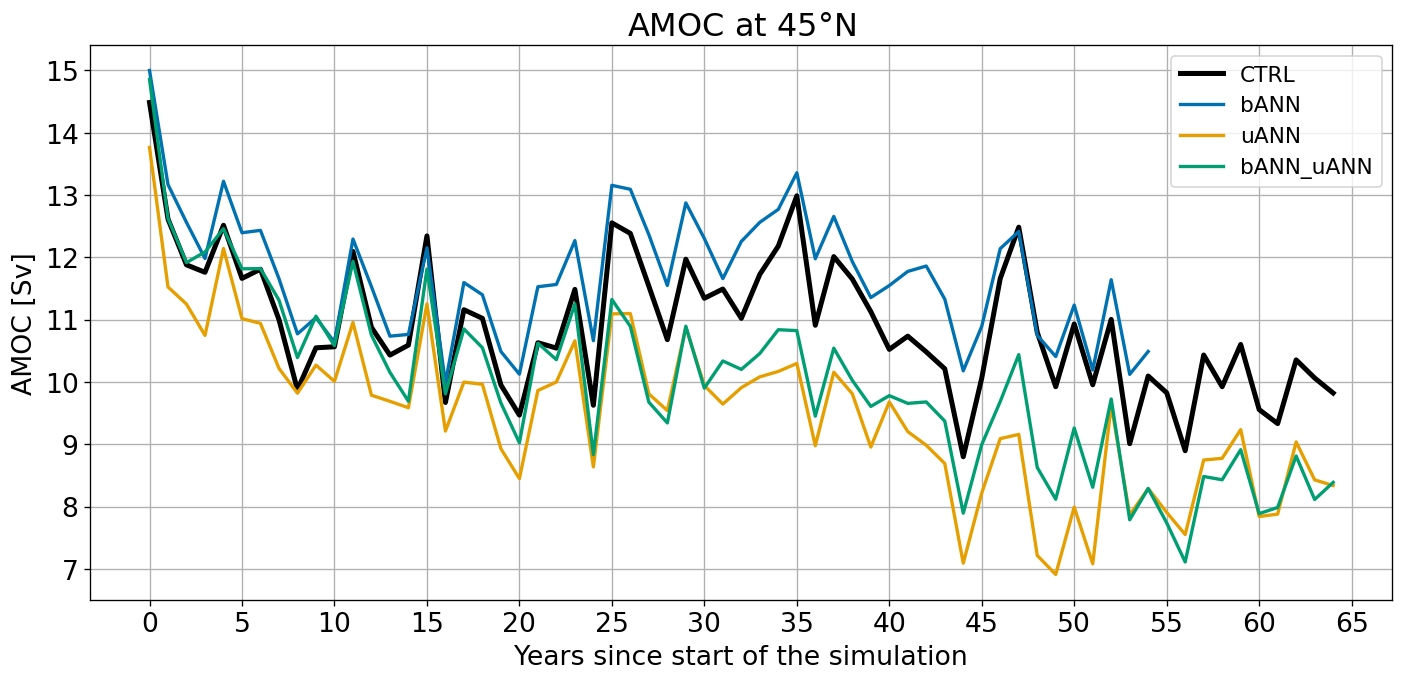

In [11]:
def _set_year_ticks(ax, times):
    """Label the time axis as years since each experiment's own start
    (5-year ticks). Experiments have different-length records (GFDL's raw
    data availability differs per experiment), so this is computed once per
    call against whichever experiment's time axis is passed in."""
    y0 = times[0].year
    years = list(range(y0, times[-1].year + 2, 5))
    ax.set_xticks([type(times[0])(y, 1, 1) for y in years])
    ax.set_xticklabels([y - y0 for y in years])


def plot_amoc_ts(var, title):
    fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
    ts = None
    for name in names:
        ds = exps[name].moc()
        ts = ds[var]
        is_ctrl = name == CTRL
        ts.plot(ax=ax, label=LABELS[name], lw=3 if is_ctrl else 2,
               color=COLORS[name])
    _set_year_ticks(ax, ts.time.values)
    ax.set_title(title)
    ax.set_xlabel('Years since start of the simulation')
    ax.set_ylabel('AMOC [Sv]')
    ax.grid(True)
    ax.legend(loc='best', fontsize=13)
    plt.show()


plot_amoc_ts('amoc_26', r'AMOC at 26.5$\degree$N (RAPID latitude)')
plot_amoc_ts('amoc_45', r'AMOC at 45$\degree$N')